# Análisis de PAT (Pulse Arrival Time) — ECG + PPG
PAT = t(dPPG/dt máx) − t(pico R del ECG), latido a latido.
- ECG: Pan-Tompkins (pasabanda → derivada → cuadrado → integración de ventana móvil), con compuerta RR contra ruido de movimiento.
- PPG: selector V5 entre pleth_1..pleth_6 por SQI espectral + coincidencia con FC del ECG; un único canal para las 6 señales.
- Todos los filtros con `filtfilt` (fase cero): sin retardo de grupo, clave para medir tiempos.

Primero se definen las funciones; después: 1° análisis temporal, 2° frecuencial, 3° tabla resumen de todas las señales.

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, welch, periodogram
from scipy.interpolate import CubicSpline
from scipy.stats import skew

# Señales publicadas desde Google Sheets como CSV (no dependen de archivos locales)
URL = "https://docs.google.com/spreadsheets/d/e/{}/pub?gid={}&single=true&output=csv"
ARCHIVOS = {
    "signal_1_1": URL.format("2PACX-1vS6aH1sdBJ_GsoPJPDdbncpFJHWzZdnpW_5tTbJSq7hbSa4asWuQaPFH4YVMpLZPVkSDiTODwCdiYfB", 1080381188),
    "signal_1_2": URL.format("2PACX-1vSTXsf0CGkvtii_rNhxENqB3bxoyyUH0Dh7Ax9aAwG1hZqk3T55sYB30vy-42PIHHovxohflcvayPIP", 996338604),
    "signal_1_3": URL.format("2PACX-1vSAthftM39au5_zhGr33qJdef1-xnPunzmUPX7cMVqDxyU9LRoeeX5lTJ1tBmPvySzaOeu6daA5cINF", 396674880),
    "signal_3_1": URL.format("2PACX-1vSoXdMY2ZMmOG-PXXW2XnierIZ841d-8M1VqztMq-o6A_PGNAS4km9XVFUD8YFpMH8xbQqM0yrA-pNo", 1615677937),
    "signal_3_2": URL.format("2PACX-1vQK4tN3TYBhcT1FvCbGKqz2z2UdrYFiNejhfJGHEBLm9uNBswv7p3bYkR63XNctyME30coOFki2Mcmy", 1074891263),
    "signal_3_3": URL.format("2PACX-1vQQAlduZYLCGYGEXasqCALPDh9DvxzNnoLXKW9rHf5c6Lojb6ULyjKLCeJl9-Vr2nqAFx7LsEJRBnw6", 168510958),
}
FS = 500.0  # Hz (muestras cada 2 ms)

DIR_TAB, DIR_GRAF = "salidas/tablas", "salidas/graficos"
os.makedirs(DIR_TAB, exist_ok=True)
os.makedirs(DIR_GRAF, exist_ok=True)
print(list(ARCHIVOS))


def pasabanda(x, f1, f2, orden=3):
    b, a = butter(orden, [f1, f2], btype="band", fs=FS)
    return filtfilt(b, a, x)  # fase cero

['signal_1_1', 'signal_1_2', 'signal_1_3', 'signal_3_1', 'signal_3_2', 'signal_3_3']


## ECG — Pan-Tompkins
- Detección sobre la integración de ventana móvil (pasabanda 5–15 Hz) con umbral adaptativo SPKI/NPKI.
- **Compuerta RR:** en signal_1_2 y signal_3_3 hay ruido de movimiento entre latidos que en 5–15 Hz imita un QRS (sin compuerta, PPV ≈ 90 %). Si un QRS cae a menos del 60 % del RR reciente, se queda el candidato con mayor R en el ECG de 0,5–40 Hz, donde el R es mucho más alto que el ruido.
- **Pico R** = máximo del ECG de 0,5–40 Hz en ±100 ms. Ubicarlo en el ECG de 5–15 Hz lo corría ~2 ms respecto de la referencia `peaks`, sesgo que pasaba directo al PAT.

In [14]:
def pan_tompkins(ecg):
    ecg0 = ecg - np.median(ecg)
    ecg_f = pasabanda(ecg0, 5, 15)
    signo = -1 if skew(ecg_f) < 0 else 1  # QRS invertido: dejar R positivo
    ecg_f = signo * ecg_f
    ecg_a = signo * pasabanda(ecg0, 0.5, 40)  # banda ancha: R alto y afilado frente al ruido
    der = np.gradient(ecg_f) * FS
    cuad = der ** 2
    win = int(0.150 * FS)  # 150 ms
    mwi = np.convolve(cuad, np.ones(win) / win, mode="same")

    # Pico R = máximo del ECG de banda ancha en ±100 ms alrededor del QRS integrado
    w = int(0.100 * FS)
    def pico_r(q):
        i0, i1 = max(q - w, 0), min(q + w, len(ecg_a))
        return i0 + np.argmax(ecg_a[i0:i1])

    # Umbral adaptativo sobre la integración (SPKI/NPKI clásico, simplificado)
    cand, _ = find_peaks(mwi, distance=int(0.25 * FS))  # refractario 250 ms
    spki, npki = np.percentile(mwi[cand], 90), np.percentile(mwi[cand], 30)
    qrs = []
    for c in cand:
        umbral = npki + 0.25 * (spki - npki)
        if mwi[c] <= umbral:
            npki = 0.125 * mwi[c] + 0.875 * npki
        elif len(qrs) >= 3 and c - qrs[-1] < 0.6 * np.median(np.diff(qrs[-9:])):
            # Compuerta RR: a < 60 % del RR reciente es ruido u onda T; queda el de mayor R en banda ancha
            if ecg_a[pico_r(c)] > ecg_a[pico_r(qrs[-1])]:
                qrs[-1] = c
        else:
            spki = 0.125 * mwi[c] + 0.875 * spki
            qrs.append(c)
    return np.unique([pico_r(q) for q in qrs]), ecg_a

## PPG — Selector inteligente V5 (SQI espectral + coincidencia cardíaca)
- Pasabanda 0.5–8 Hz: corta el artefacto de movimiento/respiración (<0.5 Hz).
- SQI = potencia en ±0.2 Hz de la FC (y 2° armónico) / potencia total 0.5–8 Hz.
- Coincidencia: pico espectral dominante del PPG vs FC del ECG.
- Polaridad: la subida sistólica es rápida → se elige el signo con derivada de asimetría positiva.
- **Canal único:** el PAT depende del sitio y de la longitud de onda (hasta ~50 ms entre canales en una misma señal). Elegir el mejor canal en cada señal mezclaría ese efecto con la fisiología, así que para las 6 señales se usa el canal con mejor score en su peor señal (máximo del mínimo).

In [15]:
def sqi_ppg(x, fc_hz):
    f, p = welch(x, fs=FS, nperseg=int(16 * FS))
    banda = (f >= 0.5) & (f <= 8)
    cerca = lambda f0: np.abs(f - f0) <= 0.2
    sqi = p[cerca(fc_hz) | cerca(2 * fc_hz)].sum() / p[banda].sum()
    f_dom = f[banda][np.argmax(p[banda])]
    coincide = np.exp(-abs(f_dom - fc_hz) / 0.15)  # 1 si coincide con la FC
    return sqi, f_dom, sqi * coincide


def seleccionar_ppg(df, fc_hz, canal=None):
    ppg_f, tabla = {}, []
    for c in [f"pleth_{i}" for i in range(1, 7)]:
        x = pasabanda(df[c].to_numpy(float), 0.5, 8)
        if skew(np.gradient(x)) < 0:
            x = -x
        ppg_f[c] = x
        sqi, f_dom, score = sqi_ppg(x, fc_hz)
        tabla.append((c, sqi, f_dom * 60, score))
    tabla = pd.DataFrame(tabla, columns=["canal", "SQI", "FC_ppg_lpm", "score"]).sort_values("score", ascending=False)
    mejor = canal or tabla.iloc[0]["canal"]  # canal forzado o el de mejor score
    return mejor, ppg_f[mejor], tabla

## PAT latido a latido
Máximo de dPPG/dt entre R+80 ms y el R siguiente (máx. 800 ms), con interpolación parabólica
(resolución < 2 ms). Se descartan latidos con PAT fuera de mediana ± 3·MAD o con RR a más de ±20 % de la mediana local de 9 latidos (R mal detectado o latido ectópico, criterio tipo Malik).

In [16]:
def calcular_pat(r_idx, dppg):
    pat_t, pat, rr = [], [], []
    for i, r in enumerate(r_idx[:-1]):
        i0 = r + int(0.08 * FS)
        i1 = min(r_idx[i + 1], r + int(0.8 * FS))
        if i1 <= i0:
            continue
        k = i0 + np.argmax(dppg[i0:i1])
        y0, y1, y2 = dppg[k - 1], dppg[k], dppg[k + 1]
        den = y0 - 2 * y1 + y2
        dk = np.clip(0.5 * (y0 - y2) / den, -0.5, 0.5) if den != 0 else 0.0  # máx. en el borde: no extrapolar
        pat_t.append(r / FS)
        pat.append((k + dk - r) / FS * 1000)  # ms
        rr.append((r_idx[i + 1] - r) / FS * 1000)  # ms
    pat_t, pat, rr = map(np.array, (pat_t, pat, rr))
    med = np.median(pat)
    mad = 1.4826 * np.median(np.abs(pat - med))
    rr_loc = pd.Series(rr).rolling(9, center=True, min_periods=1).median().to_numpy()
    ok = (np.abs(pat - med) <= 3 * mad) & (np.abs(rr / rr_loc - 1) <= 0.2)
    return pat_t, pat, rr, ok

## PSD del PAT [ms²/Hz]
- Serie latido a latido (no uniforme) → spline cúbica a 4 Hz.
- Se resta la media (sin detrend lineal, para no borrar ULF/VLF).
- Periodograma Hann sobre todo el registro: resolución 1/T ≈ 0,002 Hz (Welch con segmentos cortos borraría ULF/VLF).
- Potencia por banda = integral de la PSD (trapecios) → ms².

⚠️ Con ~500 s la ULF (< 0,003 Hz, períodos > 5,5 min) cae en 1–2 bins: valor orientativo
(la ULF se define para registros de 24 h).

In [17]:
FS_I = 4.0  # Hz, remuestreo uniforme
BANDAS = {"ULF": (0.0, 0.003, "#8e44ad"), "VLF": (0.003, 0.04, "#2980b9"),
          "LF": (0.04, 0.15, "#27ae60"), "HF": (0.15, 0.4, "#e67e22")}


def psd_pat(pat_t, pat):
    ti = np.arange(pat_t[0], pat_t[-1], 1 / FS_I)
    pat_i = CubicSpline(pat_t, pat)(ti)
    pat_i -= pat_i.mean()
    f, psd = periodogram(pat_i, fs=FS_I, window="hann", nfft=2**16, scaling="density")  # ms²/Hz
    pot = {}
    for b, (f1, f2, _) in BANDAS.items():
        m = (f >= f1) & (f <= f2)
        pot[b] = np.trapezoid(psd[m], f[m])
    return ti, pat_i, f, psd, pot

## Pipeline completo por archivo

In [18]:
def analizar(nombre, df, canal=None):
    r_idx, ecg_f = pan_tompkins(df["ecg"].to_numpy(float))
    fc_hz = 1 / np.median(np.diff(r_idx) / FS)
    mejor, ppg, tabla_ppg = seleccionar_ppg(df, fc_hz, canal)
    dppg = np.gradient(ppg) * FS
    pat_t, pat, rr, ok = calcular_pat(r_idx, dppg)
    ti, pat_i, f, psd, pot = psd_pat(pat_t[ok], pat[ok])

    # Validación Pan-Tompkins contra la columna 'peaks' del dataset (tolerancia 50 ms)
    sens = ppv = np.nan
    if "peaks" in df:
        ref = np.flatnonzero(df["peaks"].to_numpy())
        sens = 100 * np.mean([np.min(np.abs(r_idx - p)) <= 0.05 * FS for p in ref])  # R reales detectados
        ppv = 100 * np.mean([np.min(np.abs(ref - r)) <= 0.05 * FS for r in r_idx])  # detecciones que son R reales

    pv = pat[ok]
    consec = ok[1:] & ok[:-1]  # diferencias sólo entre latidos válidos consecutivos
    total = sum(pot.values())
    hf = (f >= 0.15) & (f <= 0.4)
    fila = {
        "señal": nombre,
        "duración (s)": len(df) / FS,
        "canal PPG": mejor,
        "SQI PPG": tabla_ppg.set_index("canal").loc[mejor, "SQI"],
        "sens. R (%)": sens,
        "PPV R (%)": ppv,
        "latidos": len(pat),
        "válidos (%)": 100 * ok.mean(),
        "FC (lpm)": 60000 / rr[ok].mean(),
        "PAT medio (ms)": pv.mean(),
        "PAT DE (ms)": pv.std(ddof=1),
        "PAT CV (%)": 100 * pv.std(ddof=1) / pv.mean(),
        "PAT RMSSD (ms)": np.sqrt(np.mean(np.diff(pat)[consec] ** 2)),
        "PAT mín (ms)": pv.min(),
        "PAT máx (ms)": pv.max(),
        "r(PAT,RR)": np.corrcoef(pv, rr[ok])[0, 1],
        **{f"{b} (ms²)": p for b, p in pot.items()},
        "Total (ms²)": total,
        **{f"{b} (%)": 100 * p / total for b, p in pot.items()},
        "ULF/VLF": pot["ULF"] / pot["VLF"],
        "LF/HF": pot["LF"] / pot["HF"],
        "LFnu": 100 * pot["LF"] / (pot["LF"] + pot["HF"]),
        "HFnu": 100 * pot["HF"] / (pot["LF"] + pot["HF"]),
        "pico HF (Hz)": f[hf][np.argmax(psd[hf])],
    }
    fila["FR estimada (rpm)"] = 60 * fila["pico HF (Hz)"]
    return dict(fila=fila, df=df, r_idx=r_idx, ecg_f=ecg_f, mejor=mejor, ppg=ppg, dppg=dppg,
                tabla_ppg=tabla_ppg, pat_t=pat_t, pat=pat, rr=rr, ok=ok, ti=ti, pat_i=pat_i, f=f, psd=psd, pot=pot)

# 1° Análisis Temporal — picos R, curva de presión y PAT vs tiempo
Se cargan las 6 señales una vez (`DFS`). 1ª pasada: score de cada canal PPG en cada señal → `CANAL` = el de mejor score en su peor señal. 2ª pasada con ese canal (`RES`). Por señal, dos figuras:
- **(a) Ventana de 5 s:** ECG con picos R (Pan-Tompkins y referencia `peaks`), PPG y curva de presión pulsátil. Las líneas rojas marcan cada R: el retardo hasta la subida del PPG es el PAT.
- **(b) Registro completo:** tacograma R-R, presión de contacto y PAT latido a latido.

Presión = celdas de carga `lc_1` / `lc_2` bajo los sensores PPG. Sin calibrar (cuentas ADC crudas, ~85 Hz, signo arbitrario). La componente de 0,5–8 Hz es el pulso de presión; la media móvil de 2 s es la presión de contacto, que modula la amplitud y el tiempo del PPG.

In [19]:
COLS = ["ecg", "peaks", "lc_1", "lc_2"] + [f"pleth_{i}" for i in range(1, 7)]
DFS = {n: pd.read_csv(u, usecols=COLS) for n, u in ARCHIVOS.items()}

# Canal PPG único (el PAT cambia hasta ~50 ms entre canales): mejor score en la peor señal
scores = pd.DataFrame({n: analizar(n, df)["tabla_ppg"].set_index("canal")["score"] for n, df in DFS.items()})
CANAL = scores.min(axis=1).idxmax()
print(scores.round(3).to_string(), f"\nCanal para todas las señales: {CANAL}\n")
RES = [analizar(n, df, CANAL) for n, df in DFS.items()]

RESD = {R["fila"]["señal"]: R for R in RES}  # acceso por nombre

         signal_1_1  signal_1_2  signal_1_3  signal_3_1  signal_3_2  signal_3_3
canal                                                                          
pleth_1       0.752       0.738       0.008       0.542       0.692       0.579
pleth_2       0.749       0.751       0.693       0.543       0.702       0.576
pleth_3       0.757       0.797       0.663       0.597       0.739       0.598
pleth_4       0.771       0.003       0.002       0.543       0.006       0.473
pleth_5       0.831       0.002       0.003       0.559       0.006       0.528
pleth_6       0.835       0.006       0.513       0.597       0.450       0.718 
Canal para todas las señales: pleth_3



Función de gráficos del análisis temporal (se llama una vez por señal, abajo).

In [20]:
def graf_temporal(nombre):
    R = RESD[nombre]
    df = R["df"]
    t = np.arange(len(df)) / FS
    print(f"===== {nombre} =====")
    print(R["tabla_ppg"].to_string(index=False, float_format="%.3f"))
    print(f"Canal: {R['mejor']}  |  picos R: {len(R['r_idx'])}  |  vs referencia: "
          f"sensibilidad {R['fila']['sens. R (%)']:.1f} %, PPV {R['fila']['PPV R (%)']:.1f} %")
    ok, pat, pat_t, rr = R["ok"], R["pat"], R["pat_t"], R["rr"]
    print(f"PAT: {ok.sum()}/{len(pat)} latidos válidos | media {pat[ok].mean():.1f} ms "
          f"| DE {pat[ok].std(ddof=1):.1f} ms | rango {pat[ok].min():.0f}–{pat[ok].max():.0f} ms")

    # (a) Ventana de 5 s: ECG + picos R, PPG y curva de presión pulsátil
    v = (t >= 100) & (t <= 105)
    ecg_f, r_idx, ppg, dppg = R["ecg_f"], R["r_idx"], R["ppg"], R["dppg"]
    ref = np.flatnonzero(df["peaks"].to_numpy())
    rv, fv = r_idx[v[r_idx]], ref[v[ref]]
    fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    ax[0].plot(t[v], ecg_f[v], lw=0.8, label="ECG filtrado")
    ax[0].plot(t[rv], ecg_f[rv], "rv", label="R (Pan-Tompkins)")
    ax[0].plot(t[fv], ecg_f[fv], "go", mfc="none", ms=10, label="R referencia (peaks)")
    ax[0].set_title(f"ECG y picos R — {nombre}")
    ax[1].plot(t[v], ppg[v] / np.std(ppg), lw=0.8, label=f"{R['mejor']} filtrado")
    ax[1].plot(t[v], dppg[v] / np.std(dppg), lw=0.8, alpha=0.7, label="dPPG/dt")
    ax[1].set_title("PPG seleccionado")
    for c in ["lc_1", "lc_2"]:
        p = pasabanda(df[c].to_numpy(float), 0.5, 8)  # pulso de presión
        ax[2].plot(t[v], p[v] / np.std(p), lw=0.8, label=c)
    ax[2].set_ylabel("u.a."); ax[2].set_xlabel("Tiempo (s)")
    ax[2].set_title("Curva de presión (celdas de carga, 0,5–8 Hz)")
    for a in ax:
        for x in t[rv]:
            a.axvline(x, color="r", ls=":", lw=0.6)
        a.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{DIR_GRAF}/ventana_{nombre}.png", dpi=120)
    plt.show()

    # (b) Registro completo: tacograma R-R, presión de contacto y PAT
    fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    ax[0].plot(pat_t[ok], rr[ok], ".-", lw=0.6, ms=3, label="RR")
    ax[0].plot(pat_t[~ok], rr[~ok], "x", color="gray", label="Descartados")
    ax[0].set_ylabel("RR (ms)"); ax[0].set_title(f"Tacograma R-R — {nombre}")
    d = int(FS // 10)  # graficar a 10 Hz
    for c in ["lc_1", "lc_2"]:
        x = df[c].to_numpy(float)
        ax[1].plot(t[::d], pd.Series(x - np.median(x)).rolling(int(2 * FS), center=True).mean().to_numpy()[::d], lw=1, label=c)
    ax[1].set_ylabel("Δ cuentas ADC"); ax[1].set_title("Presión de contacto (media móvil 2 s, respecto de la mediana)")
    ax[2].plot(pat_t[ok], pat[ok], ".-", lw=0.6, ms=3, label="PAT latido a latido")
    ax[2].plot(pat_t[ok], pd.Series(pat[ok]).rolling(15, center=True).median(), "r", lw=1.5, label="Mediana móvil (15 lat.)")
    ax[2].plot(pat_t[~ok], pat[~ok], "x", color="gray", label="Descartados")
    ax[2].set_xlabel("Tiempo (s)"); ax[2].set_ylabel("PAT (ms)")
    ax[2].set_title(f"Variabilidad del PAT — {nombre} ({R['mejor']})")
    for a in ax:
        a.legend(loc="upper right"); a.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DIR_GRAF}/pat_{nombre}.png", dpi=120)
    plt.show()

### Temporal — signal_1_1

===== signal_1_1 =====
  canal   SQI  FC_ppg_lpm  score
pleth_6 0.937      71.250  0.835
pleth_5 0.933      71.250  0.831
pleth_4 0.865      71.250  0.771
pleth_3 0.849      71.250  0.757
pleth_1 0.844      71.250  0.752
pleth_2 0.840      71.250  0.749
Canal: pleth_3  |  picos R: 613  |  vs referencia: sensibilidad 100.0 %, PPV 100.0 %
PAT: 603/612 latidos válidos | media 249.9 ms | DE 5.7 ms | rango 234–266 ms


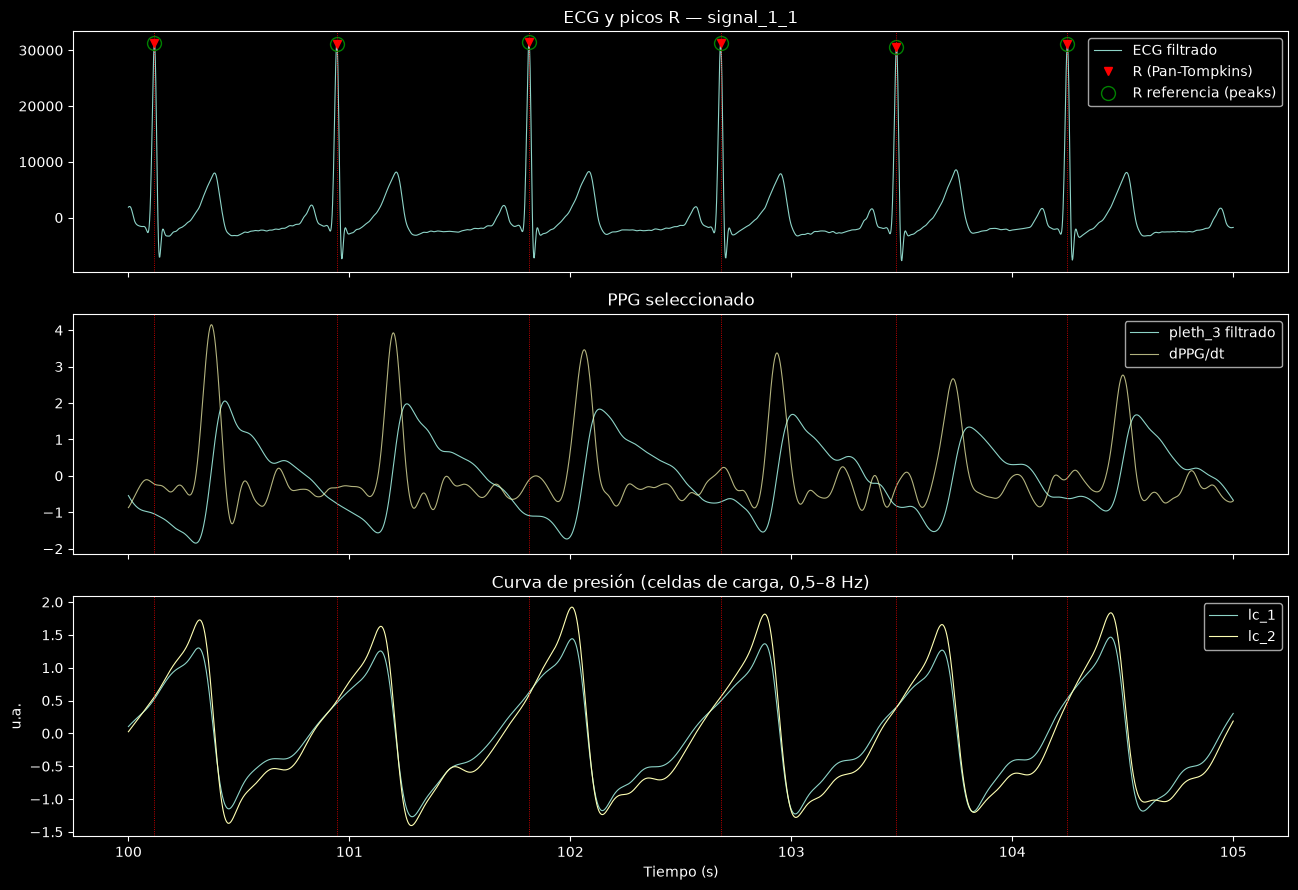

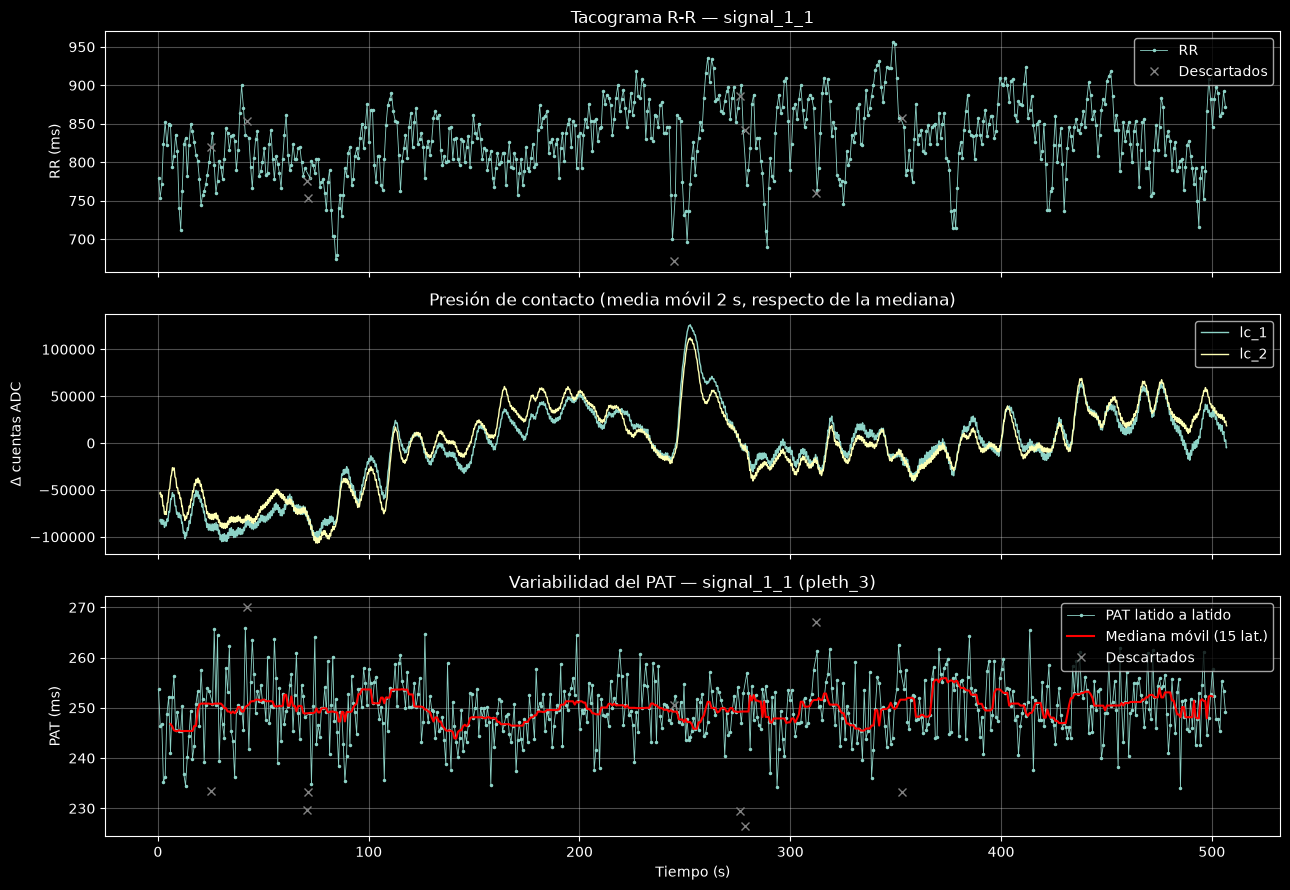

In [21]:
graf_temporal("signal_1_1")

### Temporal — signal_1_2

===== signal_1_2 =====
  canal   SQI  FC_ppg_lpm  score
pleth_3 0.823      93.750  0.797
pleth_2 0.776      93.750  0.751
pleth_1 0.762      93.750  0.738
pleth_6 0.263      60.000  0.006
pleth_4 0.115      60.000  0.003
pleth_5 0.101      60.000  0.002
Canal: pleth_3  |  picos R: 759  |  vs referencia: sensibilidad 96.9 %, PPV 97.9 %
PAT: 724/758 latidos válidos | media 237.8 ms | DE 9.5 ms | rango 213–265 ms


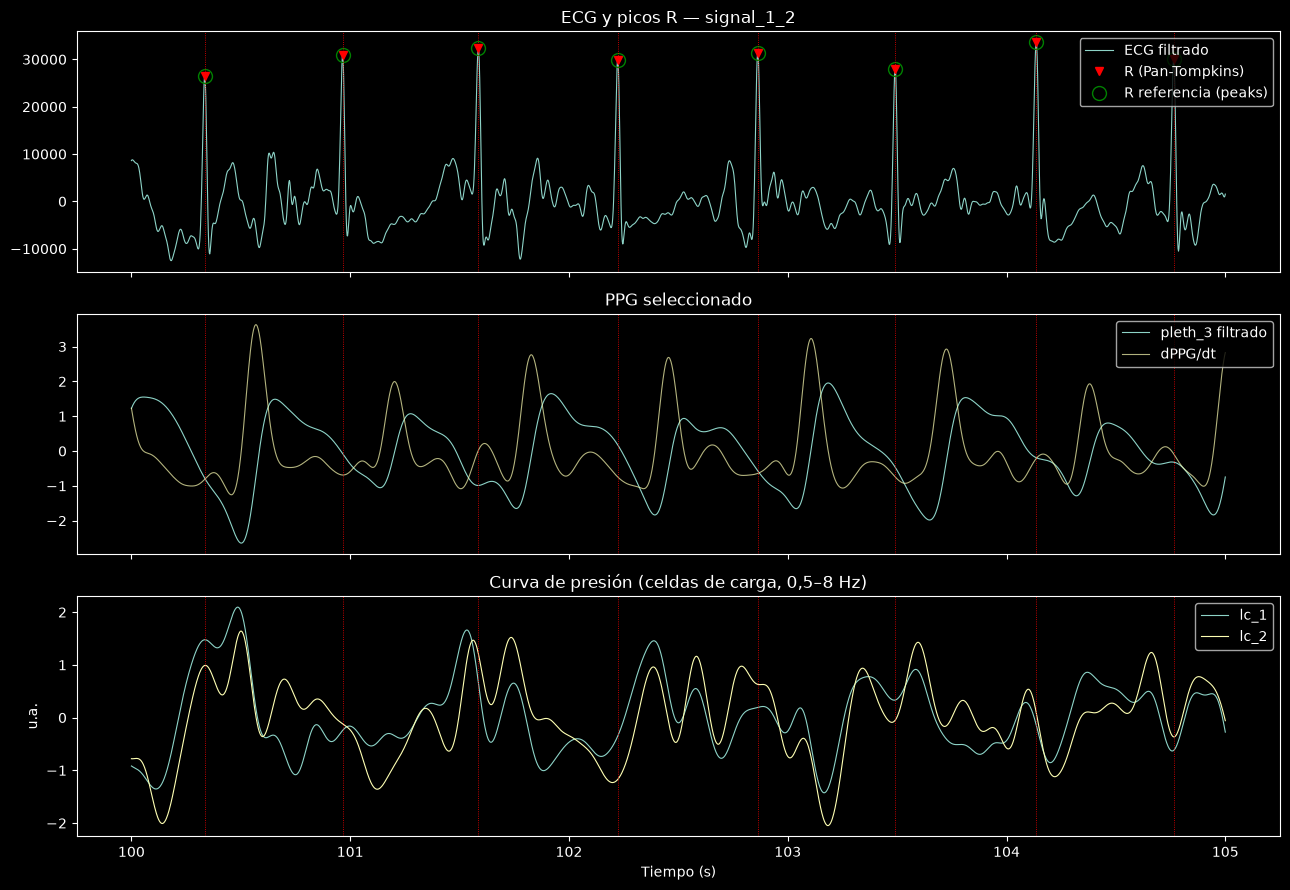

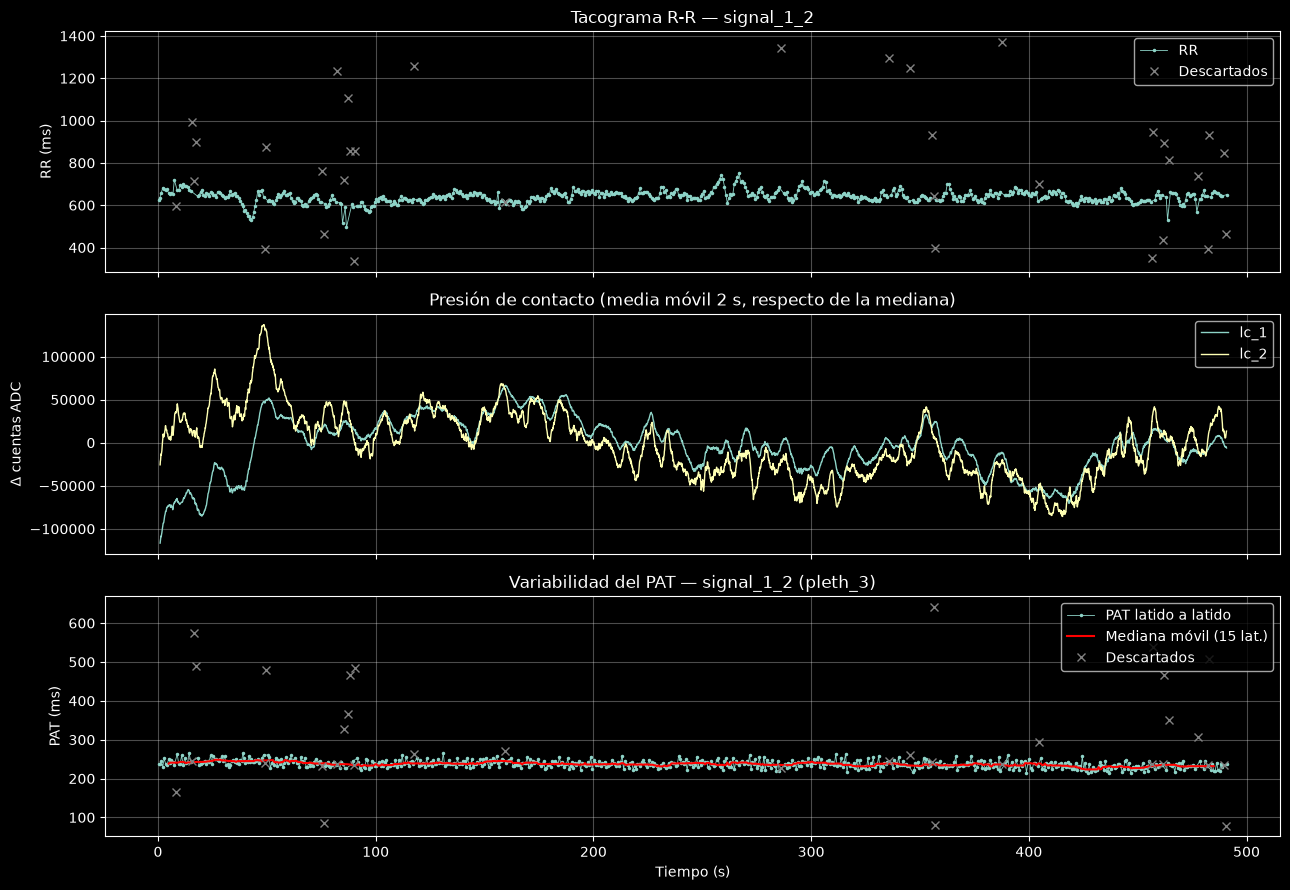

In [22]:
graf_temporal("signal_1_2")

### Temporal — signal_1_3

===== signal_1_3 =====
  canal   SQI  FC_ppg_lpm  score
pleth_2 0.835      78.750  0.693
pleth_3 0.798      78.750  0.663
pleth_6 0.618      78.750  0.513
pleth_1 0.397      45.000  0.008
pleth_5 0.148      45.000  0.003
pleth_4 0.109      45.000  0.002
Canal: pleth_3  |  picos R: 658  |  vs referencia: sensibilidad 99.4 %, PPV 99.5 %
PAT: 644/657 latidos válidos | media 242.9 ms | DE 14.4 ms | rango 201–285 ms


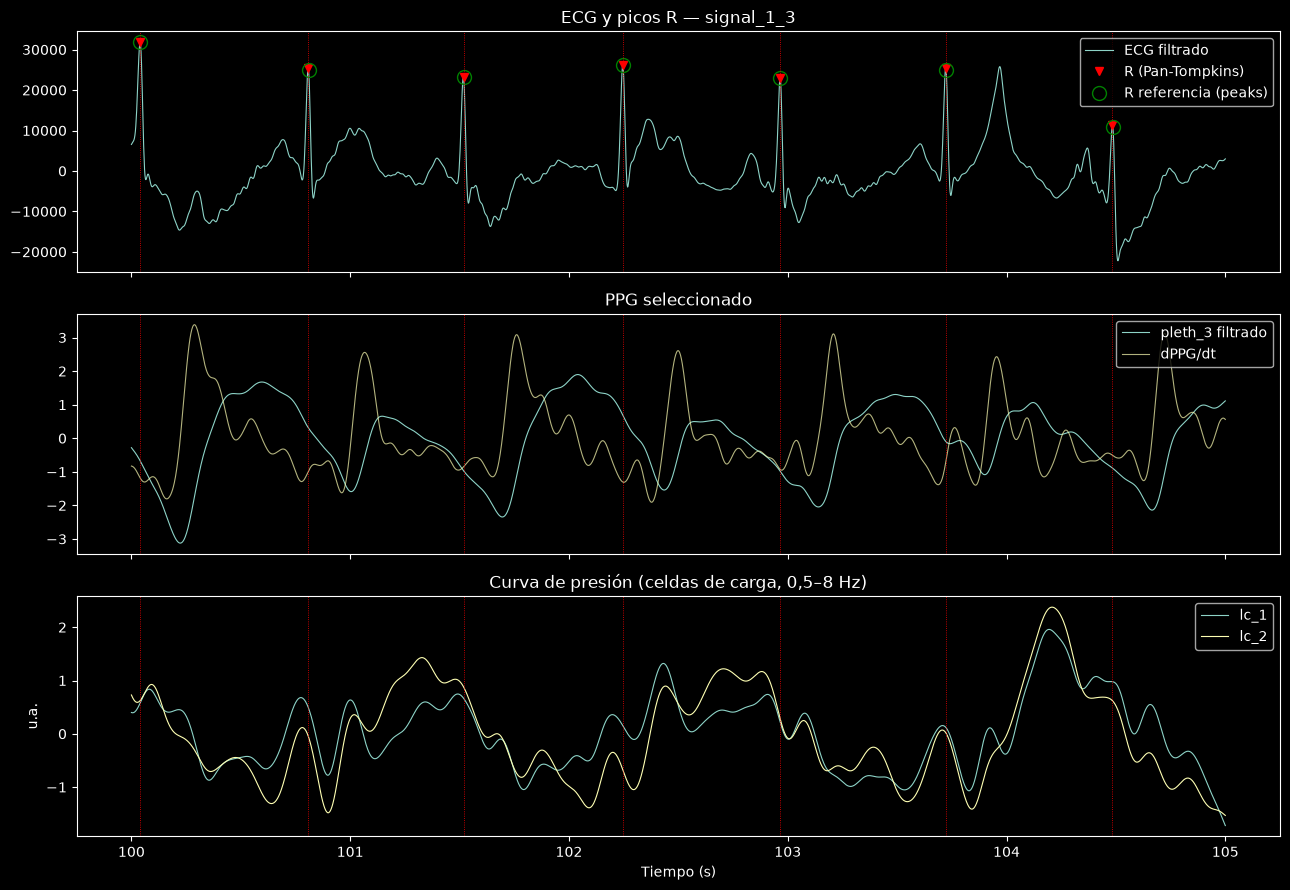

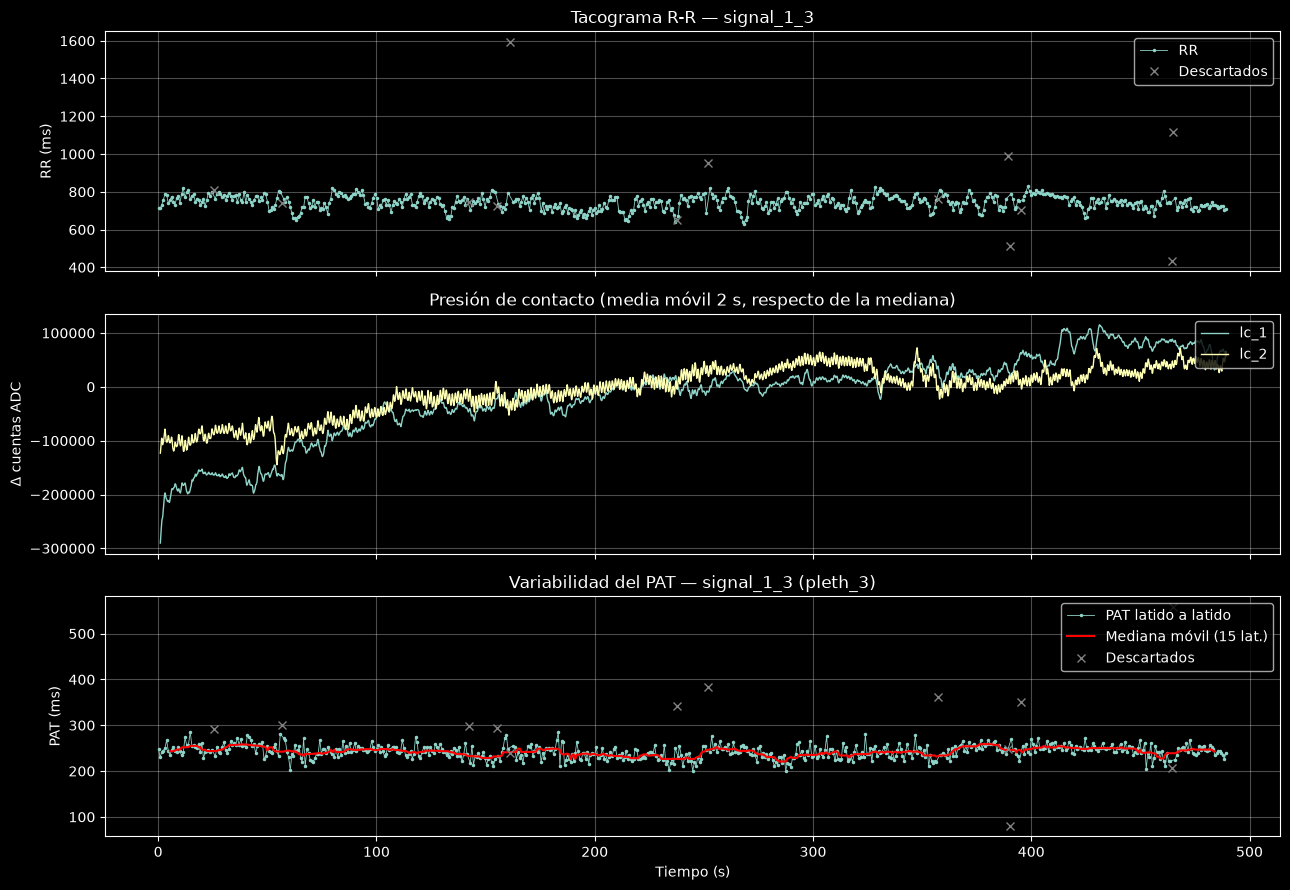

In [23]:
graf_temporal("signal_1_3")

### Temporal — signal_3_1

===== signal_3_1 =====
  canal   SQI  FC_ppg_lpm  score
pleth_3 0.809      71.250  0.597
pleth_6 0.809      71.250  0.597
pleth_5 0.758      71.250  0.559
pleth_2 0.735      71.250  0.543
pleth_4 0.735      71.250  0.543
pleth_1 0.735      71.250  0.542
Canal: pleth_3  |  picos R: 603  |  vs referencia: sensibilidad 100.0 %, PPV 100.0 %
PAT: 602/602 latidos válidos | media 291.1 ms | DE 7.4 ms | rango 272–310 ms


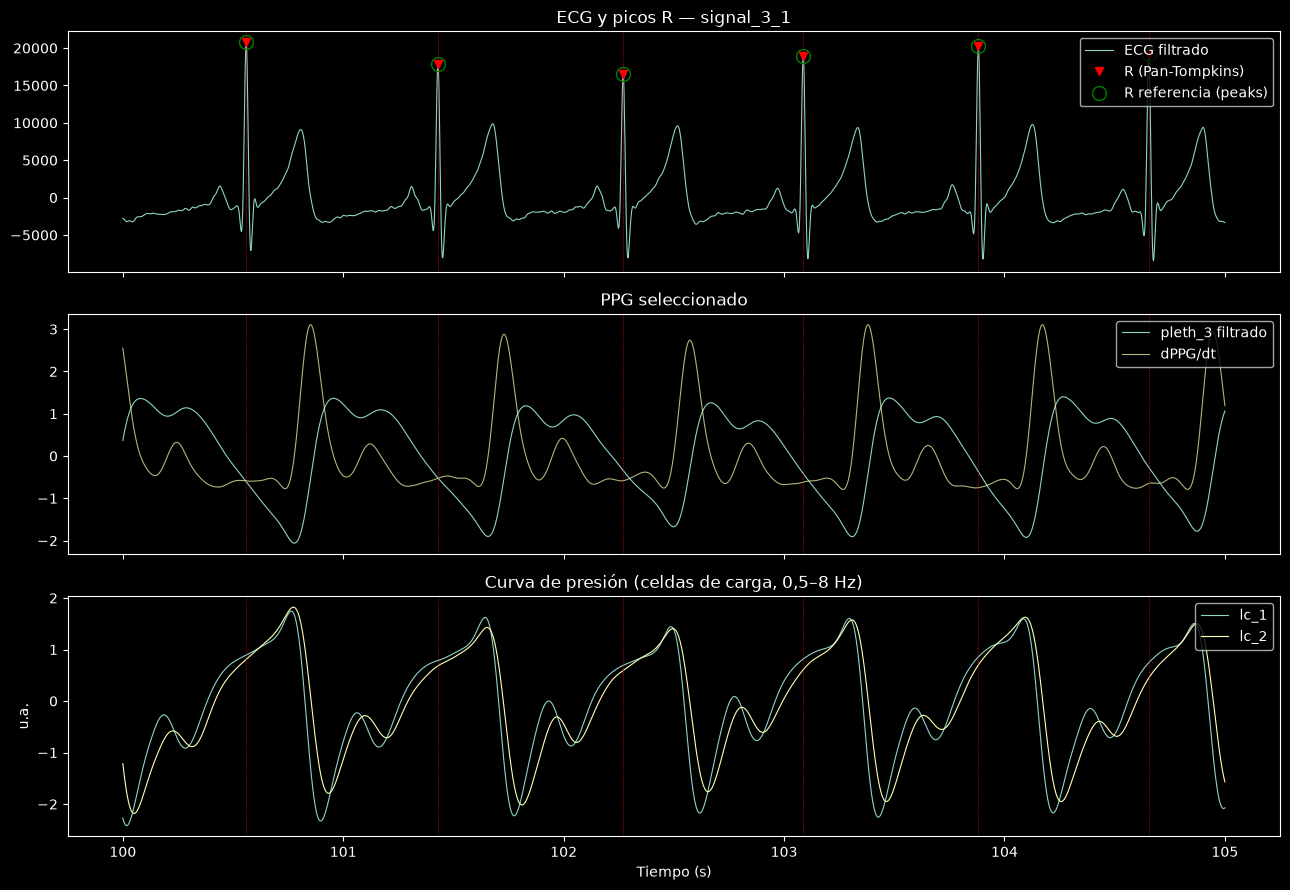

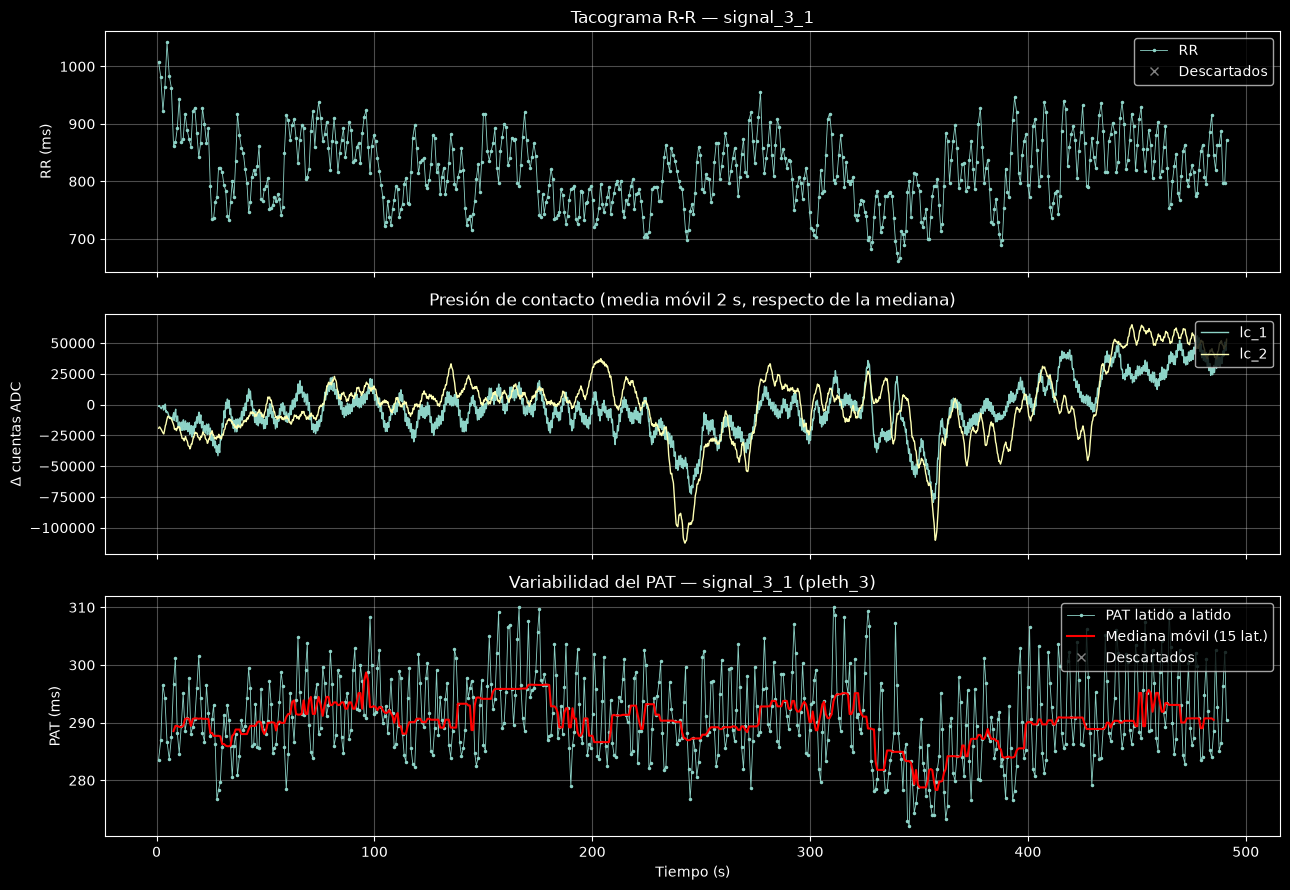

In [24]:
graf_temporal("signal_3_1")

### Temporal — signal_3_2

===== signal_3_2 =====
  canal   SQI  FC_ppg_lpm  score
pleth_3 0.784      86.250  0.739
pleth_2 0.745      86.250  0.702
pleth_1 0.734      86.250  0.692
pleth_6 0.477      86.250  0.450
pleth_4 0.238      52.500  0.006
pleth_5 0.221      52.500  0.006
Canal: pleth_3  |  picos R: 703  |  vs referencia: sensibilidad 99.9 %, PPV 99.9 %
PAT: 695/702 latidos válidos | media 267.6 ms | DE 5.5 ms | rango 251–283 ms


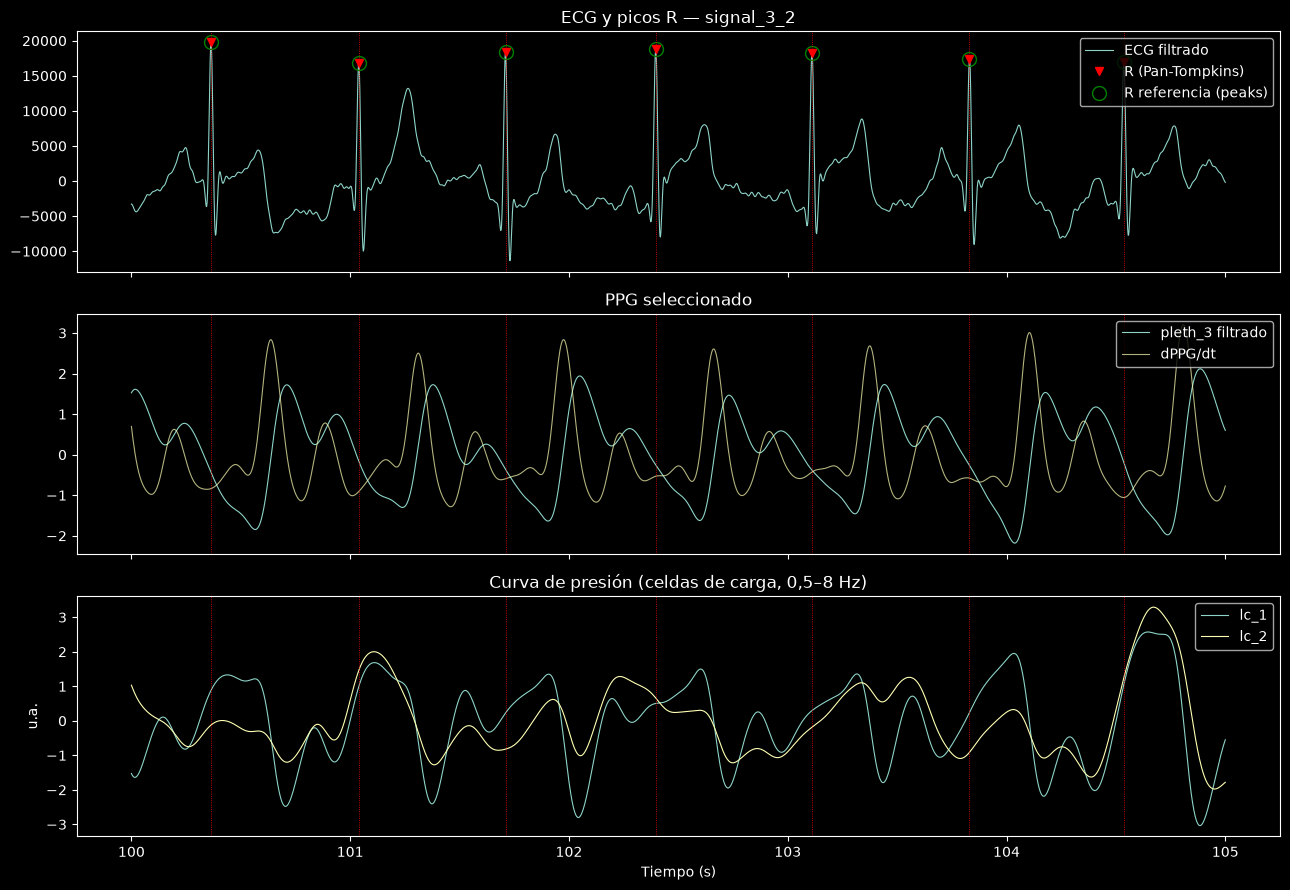

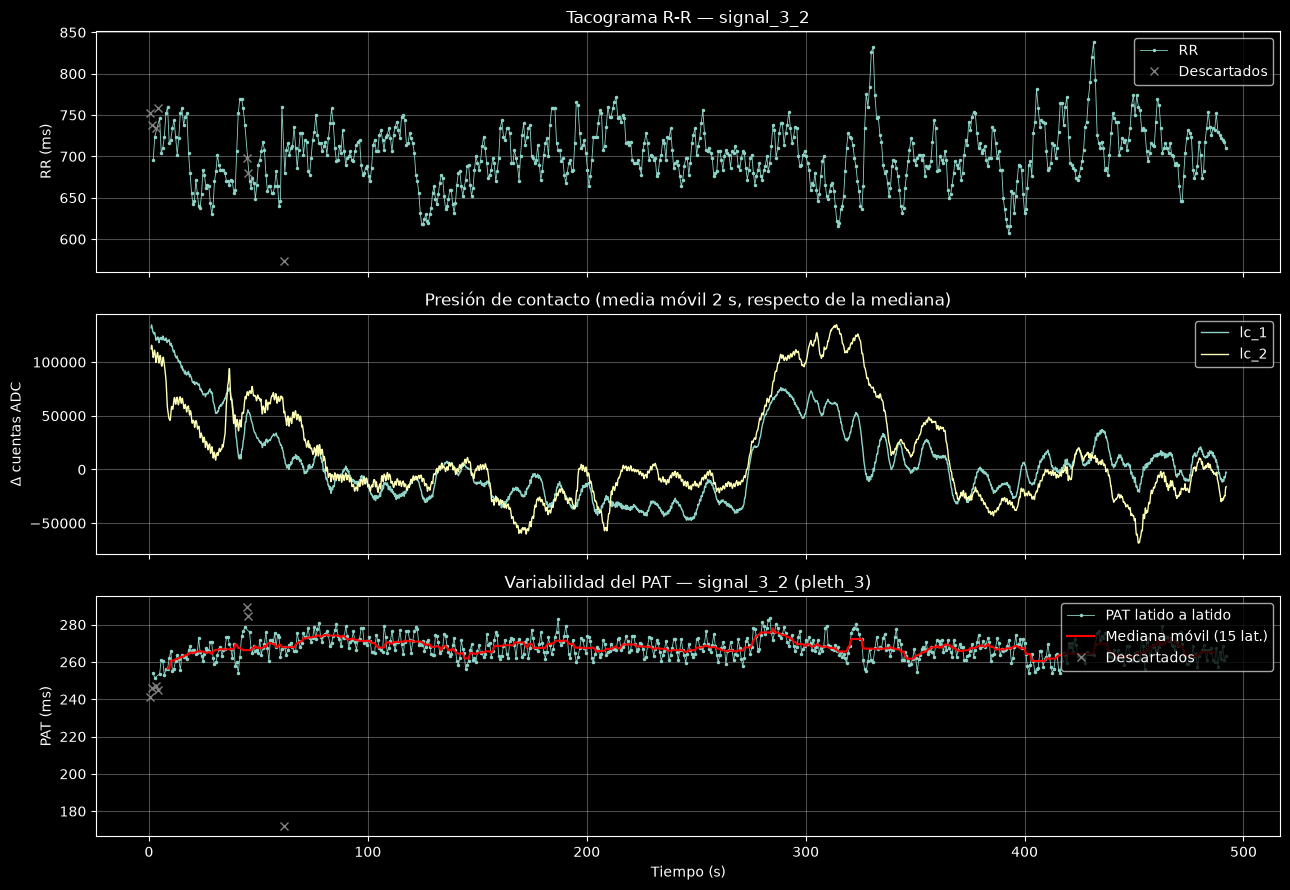

In [25]:
graf_temporal("signal_3_2")

### Temporal — signal_3_3

===== signal_3_3 =====
  canal   SQI  FC_ppg_lpm  score
pleth_6 0.805      86.250  0.718
pleth_3 0.810      82.500  0.598
pleth_1 0.783      82.500  0.579
pleth_2 0.780      82.500  0.576
pleth_5 0.592      86.250  0.528
pleth_4 0.530      86.250  0.473
Canal: pleth_3  |  picos R: 679  |  vs referencia: sensibilidad 98.3 %, PPV 99.6 %
PAT: 664/678 latidos válidos | media 276.5 ms | DE 9.6 ms | rango 255–306 ms


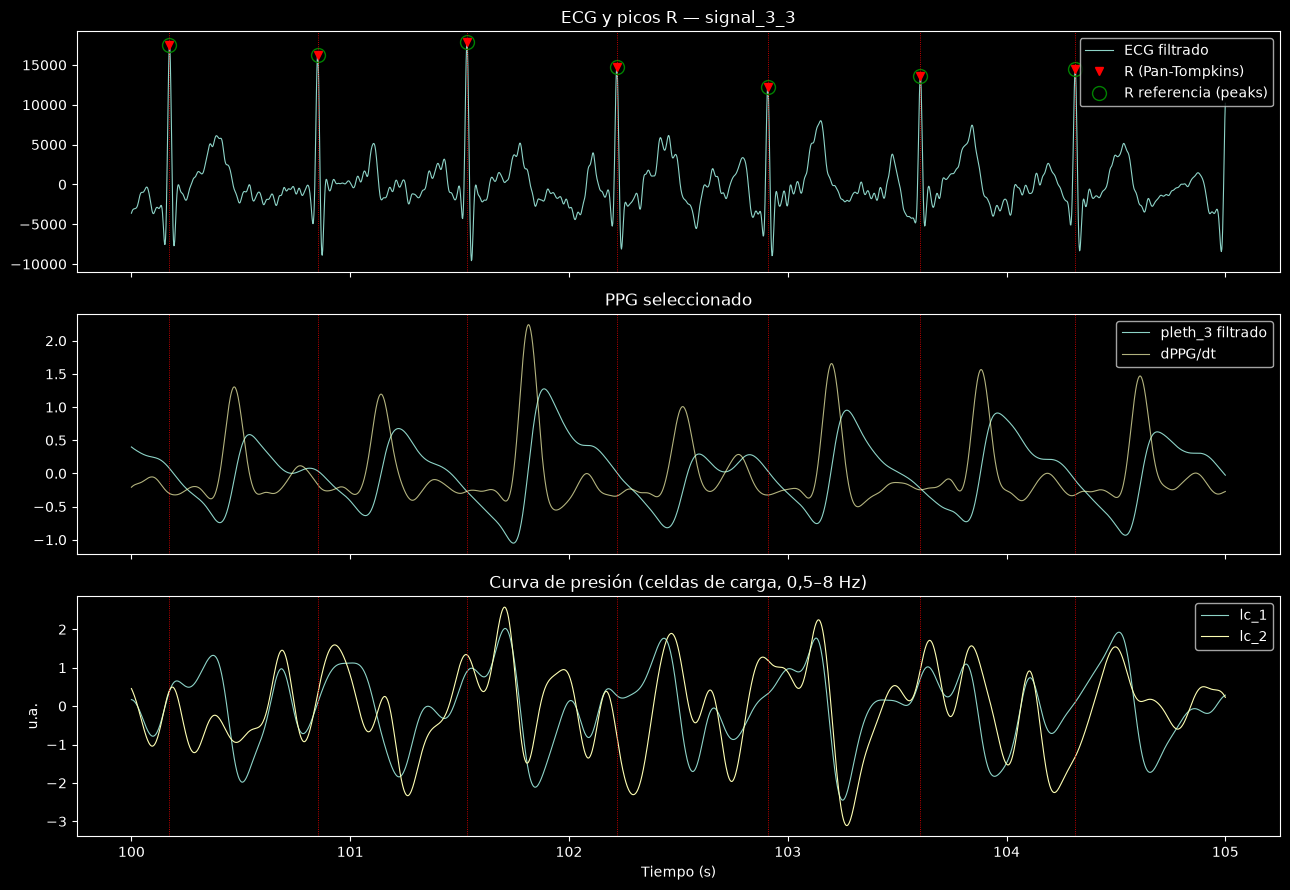

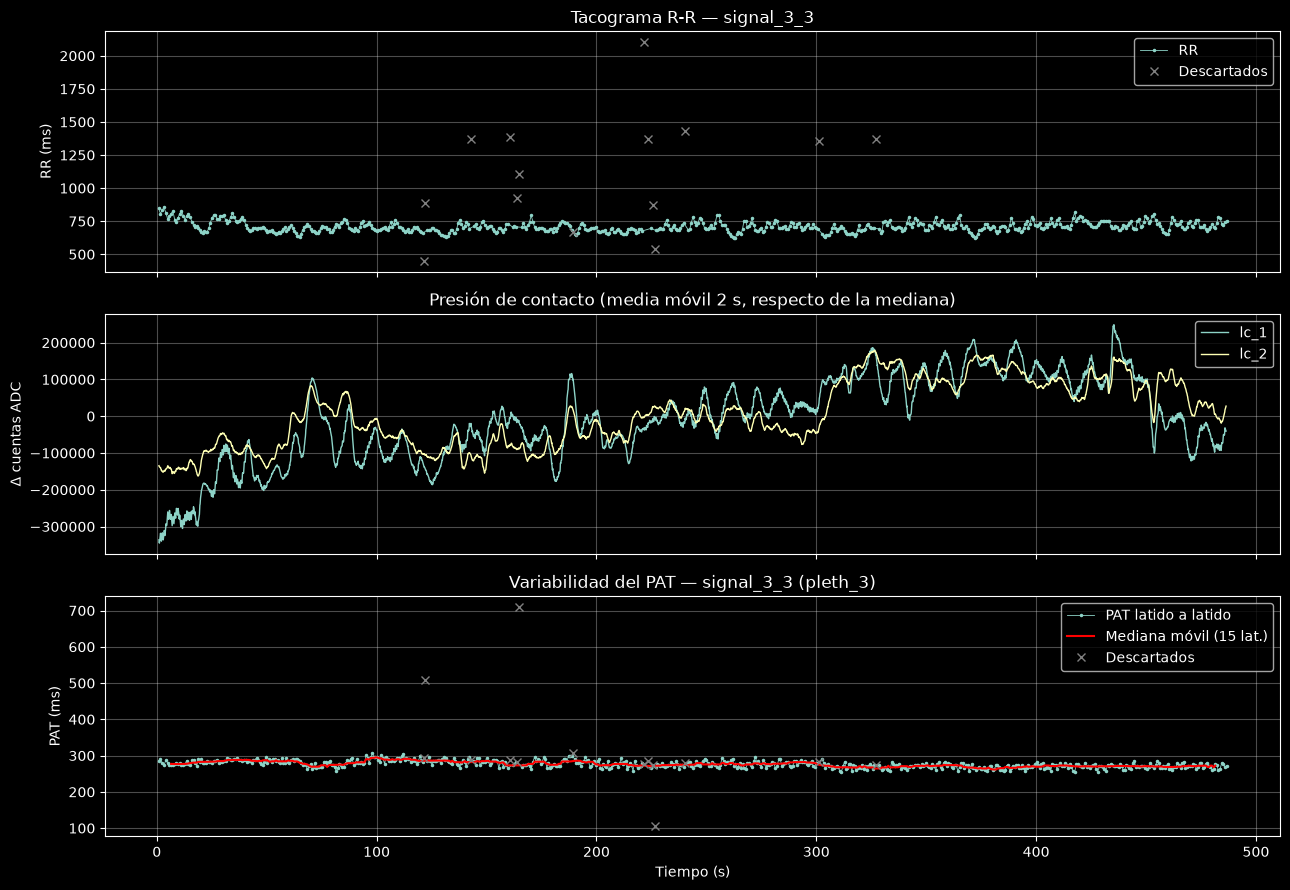

In [26]:
graf_temporal("signal_3_3")

# 2° Análisis Frecuencial — PSD por bandas
(a) PSD global del registro vs frecuencia.

In [27]:
def graf_psd(nombre):
    R = RESD[nombre]
    pat, ok = R["pat"], R["ok"]
    f, psd, pot, ti, pat_i = R["f"], R["psd"], R["pot"], R["ti"], R["pat_i"]
    total = sum(pot.values())
    print(f"===== {nombre} =====")
    print(pd.DataFrame({"Banda": list(pot), "Rango (Hz)": [f"{v[0]}–{v[1]}" for v in BANDAS.values()],
                        "Potencia (ms²)": list(pot.values()),
                        "% del total": [100 * p / total for p in pot.values()]}).to_string(index=False, float_format="%.3f"))
    print(f"Total 0–0.4 Hz: {total:.2f} ms²  |  LF/HF = {pot['LF'] / pot['HF']:.2f}")

    fig, ax = plt.subplots(2, 1, figsize=(13, 8))
    ax[0].plot(ti, pat_i + pat[ok].mean(), lw=0.8)
    ax[0].set_xlabel("Tiempo (s)"); ax[0].set_ylabel("PAT (ms)")
    ax[0].set_title(f"PAT interpolado a {FS_I:g} Hz ({ti[-1] - ti[0]:.0f} s) — entrada de la PSD — {nombre}"); ax[0].grid(alpha=0.3)

    m04 = f <= 0.4
    ax[1].plot(f[m04], psd[m04], "k", lw=1)
    for b, (f1, f2, col) in BANDAS.items():
        m = (f >= f1) & (f <= f2)
        ax[1].fill_between(f[m], psd[m], color=col, alpha=0.6,
                           label=f"{b} ({f1}–{f2} Hz): {pot[b]:.2f} ms² ({100 * pot[b] / total:.1f} %)")
        ax[1].axvline(f2, color="gray", ls=":", lw=0.8)
    ax[1].set_xlim(0, 0.4)
    ax[1].set_xlabel("Frecuencia (Hz)"); ax[1].set_ylabel("PSD (ms²/Hz)")
    ax[1].set_title(f"Densidad espectral de potencia del PAT — {nombre}")
    ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DIR_GRAF}/psd_{nombre}.png", dpi=120)
    plt.show()

### PSD — signal_1_1

===== signal_1_1 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003           0.268        1.307
  VLF 0.003–0.04           4.186       20.446
   LF  0.04–0.15           6.055       29.575
   HF   0.15–0.4           9.965       48.672
Total 0–0.4 Hz: 20.47 ms²  |  LF/HF = 0.61


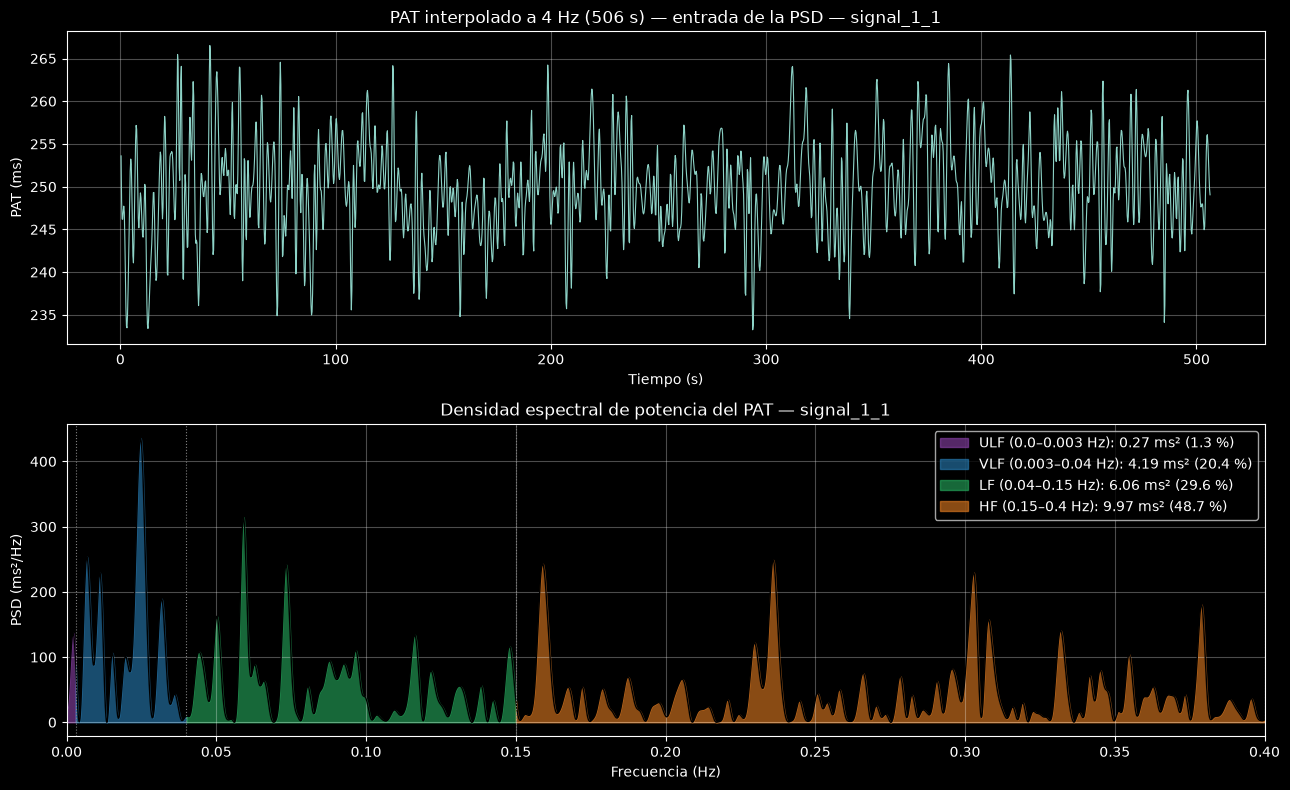

In [28]:
graf_psd("signal_1_1")

### PSD — signal_1_2

===== signal_1_2 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003           1.442        3.953
  VLF 0.003–0.04           7.134       19.554
   LF  0.04–0.15           9.477       25.976
   HF   0.15–0.4          18.431       50.517
Total 0–0.4 Hz: 36.48 ms²  |  LF/HF = 0.51


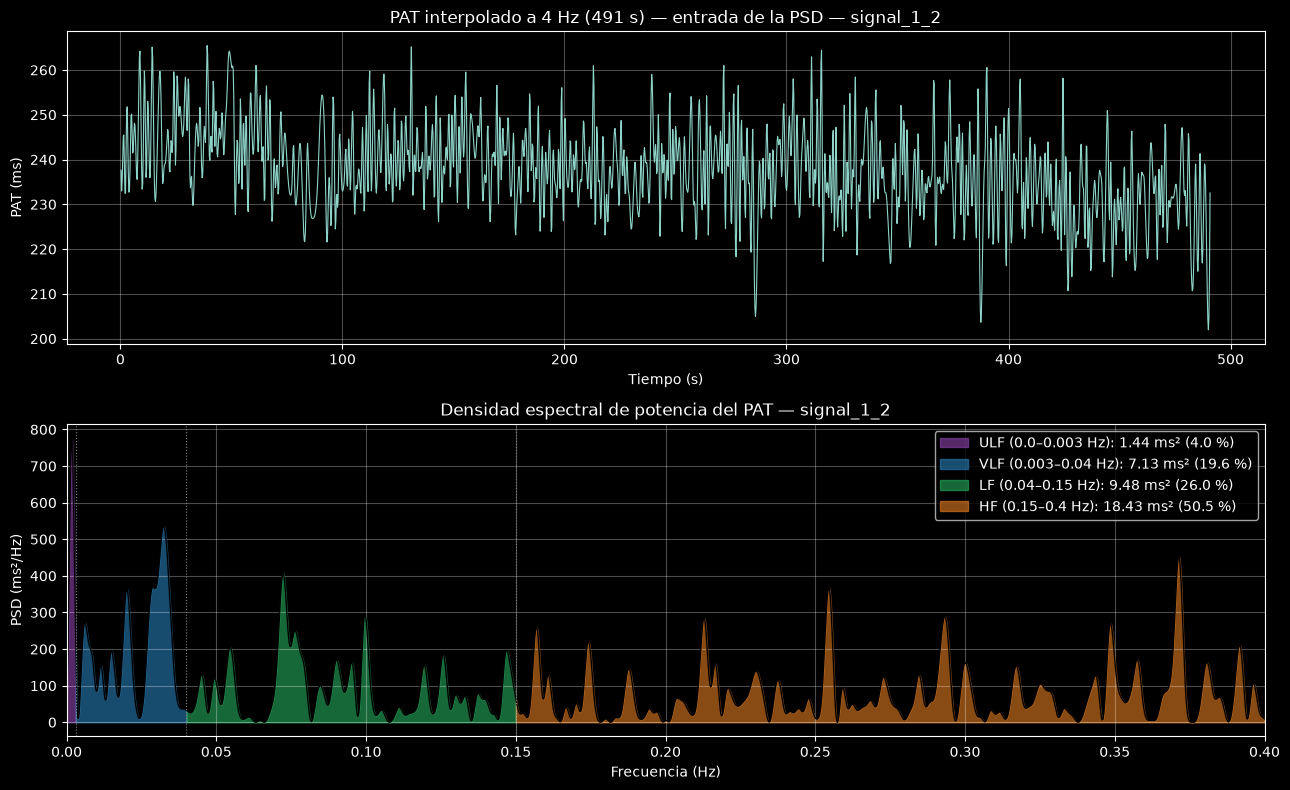

In [29]:
graf_psd("signal_1_2")

### PSD — signal_1_3

===== signal_1_3 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003          23.528       13.340
  VLF 0.003–0.04          51.751       29.343
   LF  0.04–0.15          41.875       23.743
   HF   0.15–0.4          59.211       33.573
Total 0–0.4 Hz: 176.36 ms²  |  LF/HF = 0.71


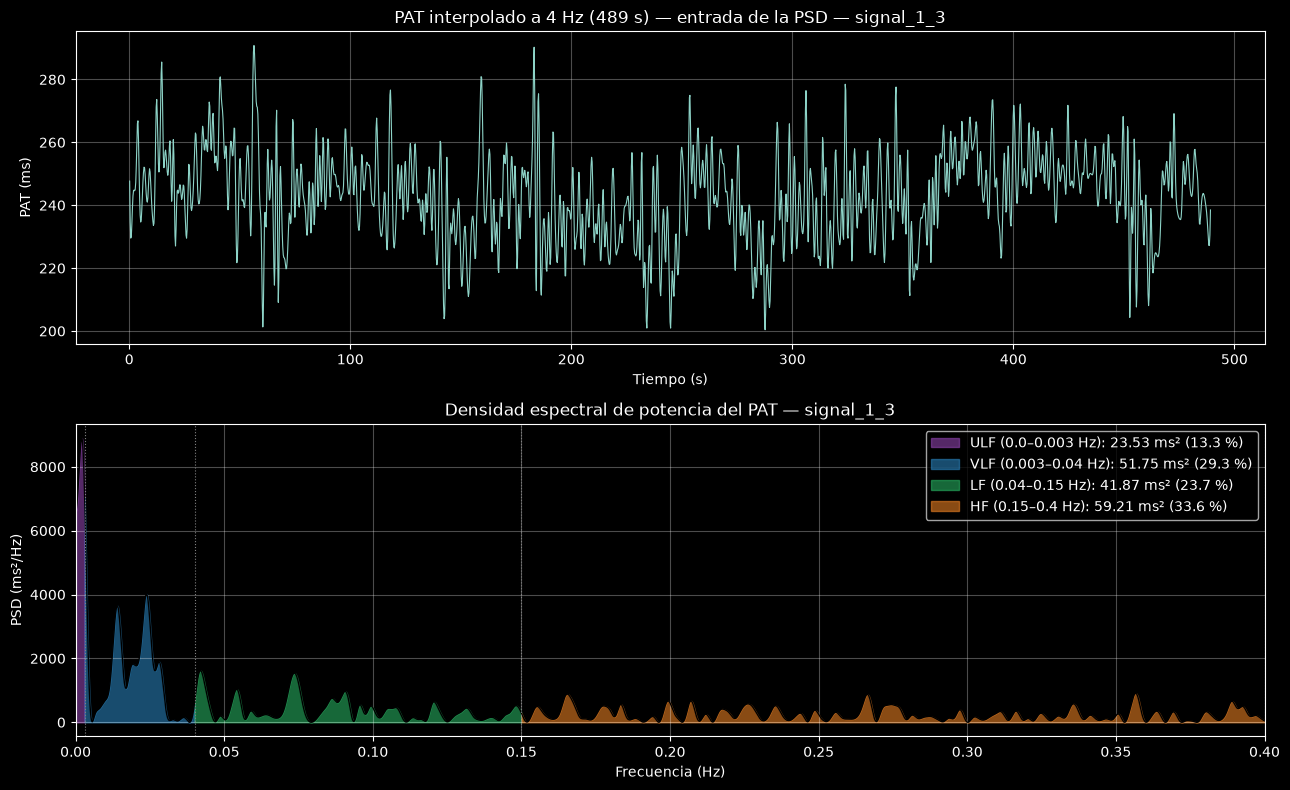

In [30]:
graf_psd("signal_1_3")

### PSD — signal_3_1

===== signal_3_1 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003           1.957        3.880
  VLF 0.003–0.04          10.415       20.646
   LF  0.04–0.15           9.843       19.511
   HF   0.15–0.4          28.231       55.963
Total 0–0.4 Hz: 50.45 ms²  |  LF/HF = 0.35


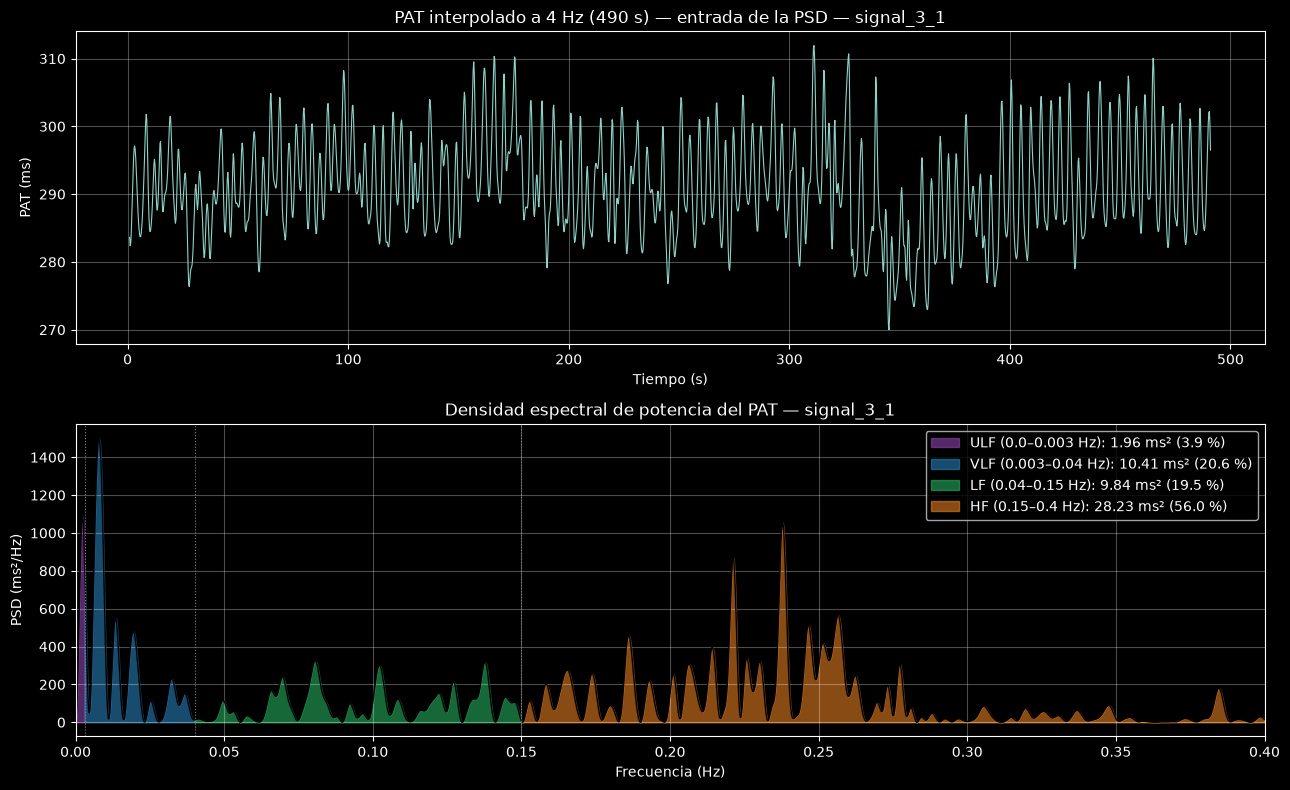

In [31]:
graf_psd("signal_3_1")

### PSD — signal_3_2

===== signal_3_2 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003           0.761        3.010
  VLF 0.003–0.04           7.515       29.711
   LF  0.04–0.15           5.823       23.023
   HF   0.15–0.4          11.194       44.256
Total 0–0.4 Hz: 25.29 ms²  |  LF/HF = 0.52


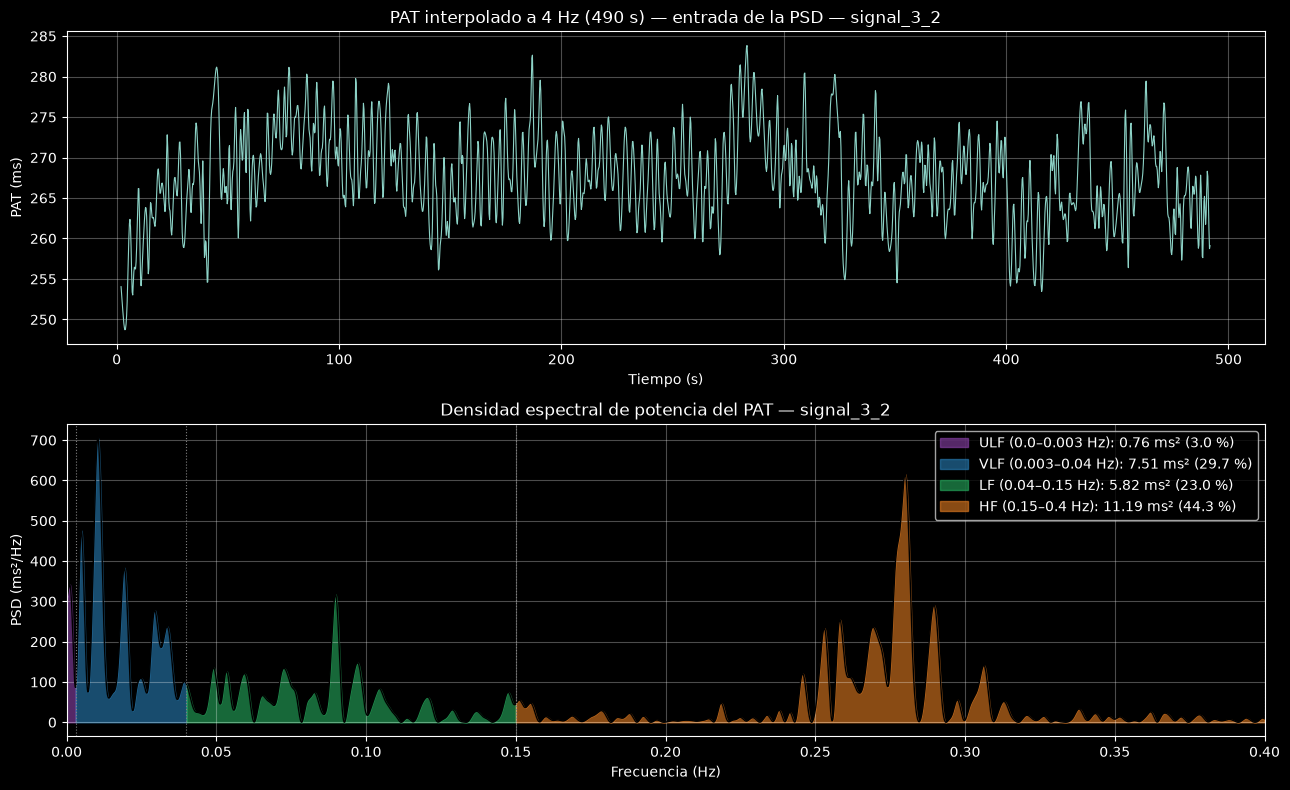

In [32]:
graf_psd("signal_3_2")

### PSD — signal_3_3

===== signal_3_3 =====
Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003          11.009       16.216
  VLF 0.003–0.04          15.640       23.037
   LF  0.04–0.15          19.011       28.004
   HF   0.15–0.4          22.230       32.744
Total 0–0.4 Hz: 67.89 ms²  |  LF/HF = 0.86


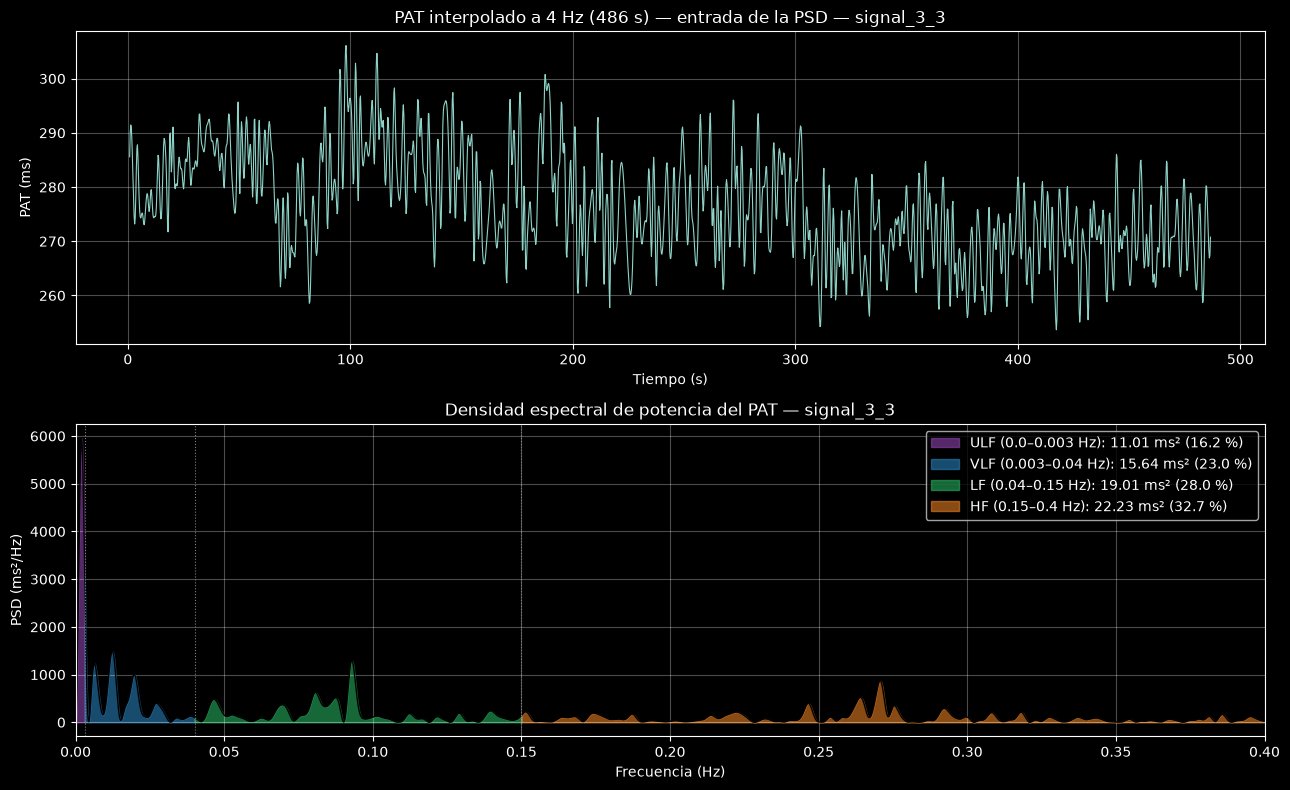

In [33]:
graf_psd("signal_3_3")

## 2° (b) PSD por bandas vs tiempo (500 s)
La PSD es una función de la frecuencia; para verla a lo largo de los ~500 s se usa un espectrograma (STFT, ventana Hann de 120 s, paso 10 s, fase cero no aplica: sólo se estima potencia).
- Arriba: PSD [ms²/Hz] en color, tiempo en X, frecuencia en Y con los límites de banda.
- Abajo: PSD media de cada banda [ms²/Hz] vs tiempo, con color bajo la curva.

⚠️ Con ventanas de 120 s la resolución es ≈ 0,008 Hz: la ULF (< 0,003 Hz) no se puede resolver en el tiempo y la VLF sólo parcialmente. Por eso ULF queda fuera de este gráfico (está en la PSD global).

In [34]:
from scipy.signal import spectrogram

VENT = 120  # s
def graf_espectrograma(nombre):
    R = RESD[nombre]
    ti, pat_i = R["ti"], R["pat_i"]
    fs_, ts_, Sxx = spectrogram(pat_i, fs=FS_I, window="hann", nperseg=int(VENT * FS_I),
                                noverlap=int((VENT - 10) * FS_I), nfft=2**12, scaling="density")
    ts_ = ts_ + ti[0]

    fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True, layout="constrained")
    m04 = fs_ <= 0.4
    im = ax[0].pcolormesh(ts_, fs_[m04], Sxx[m04], shading="gouraud", cmap="viridis")
    fig.colorbar(im, ax=ax, label="PSD (ms²/Hz)", shrink=0.5, anchor=(0, 1))
    for b, (f1, f2, col) in BANDAS.items():
        ax[0].axhline(f2, color="w", ls="--", lw=0.8)
        ax[0].text(ts_[0] + 2, (f1 + f2) / 2, b, color="w", va="center", fontsize=9, fontweight="bold")
    ax[0].set_ylabel("Frecuencia (Hz)"); ax[0].set_ylim(0, 0.4)
    ax[0].set_title(f"Espectrograma del PAT — {nombre} (ventana {VENT} s)")

    for b, (f1, f2, col) in list(BANDAS.items())[1:]:  # ULF no resoluble con 120 s
        m = (fs_ >= f1) & (fs_ <= f2)
        dens = Sxx[m].mean(axis=0)
        ax[1].plot(ts_, dens, color=col, lw=1.2)
        ax[1].fill_between(ts_, dens, color=col, alpha=0.35, label=f"{b} ({f1}–{f2} Hz)")
    ax[1].set_xlabel("Tiempo (s)"); ax[1].set_ylabel("PSD media de banda (ms²/Hz)")
    ax[1].set_title(f"PSD por bandas a lo largo del registro — {nombre}")
    ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
    ax[1].set_xlim(0, ti[-1])
    plt.savefig(f"{DIR_GRAF}/psd_tiempo_{nombre}.png", dpi=120)
    plt.show()

### Espectrograma — signal_1_1

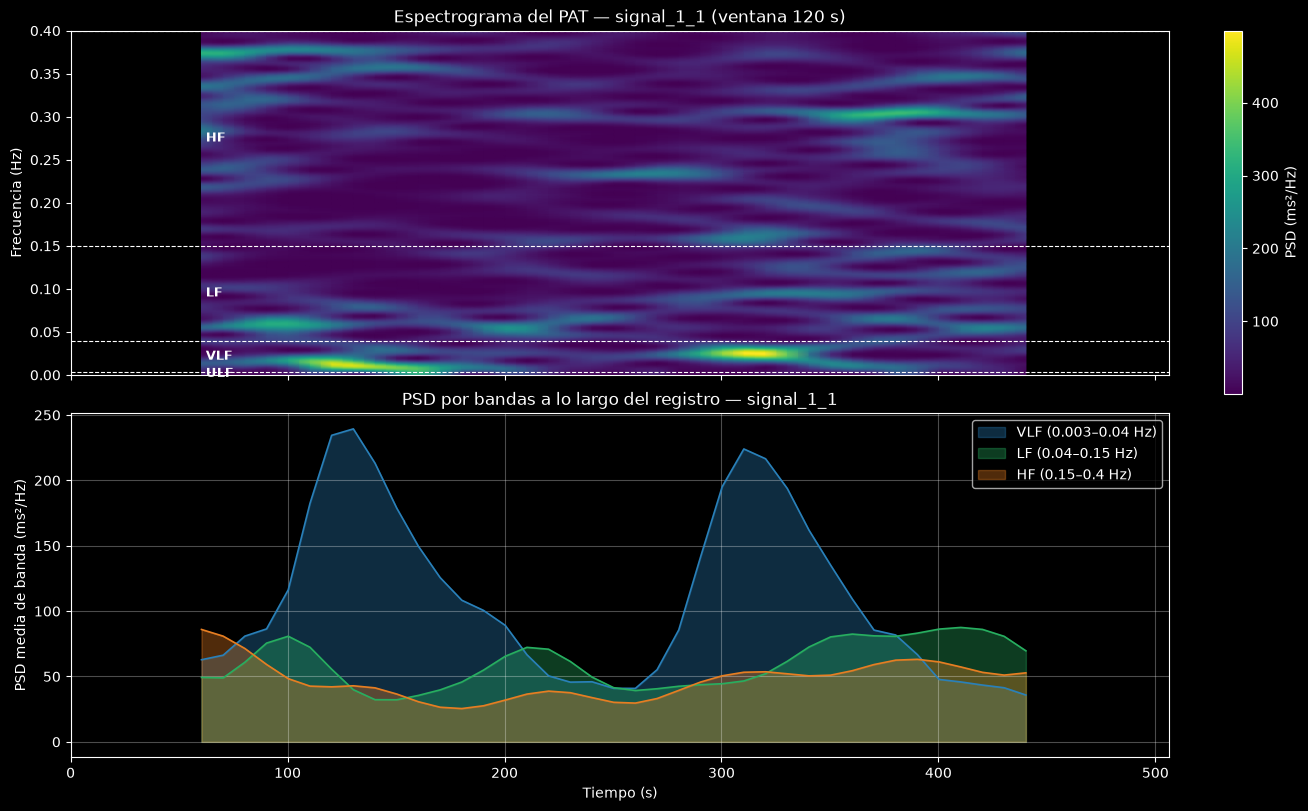

In [35]:
graf_espectrograma("signal_1_1")

### Espectrograma — signal_1_2

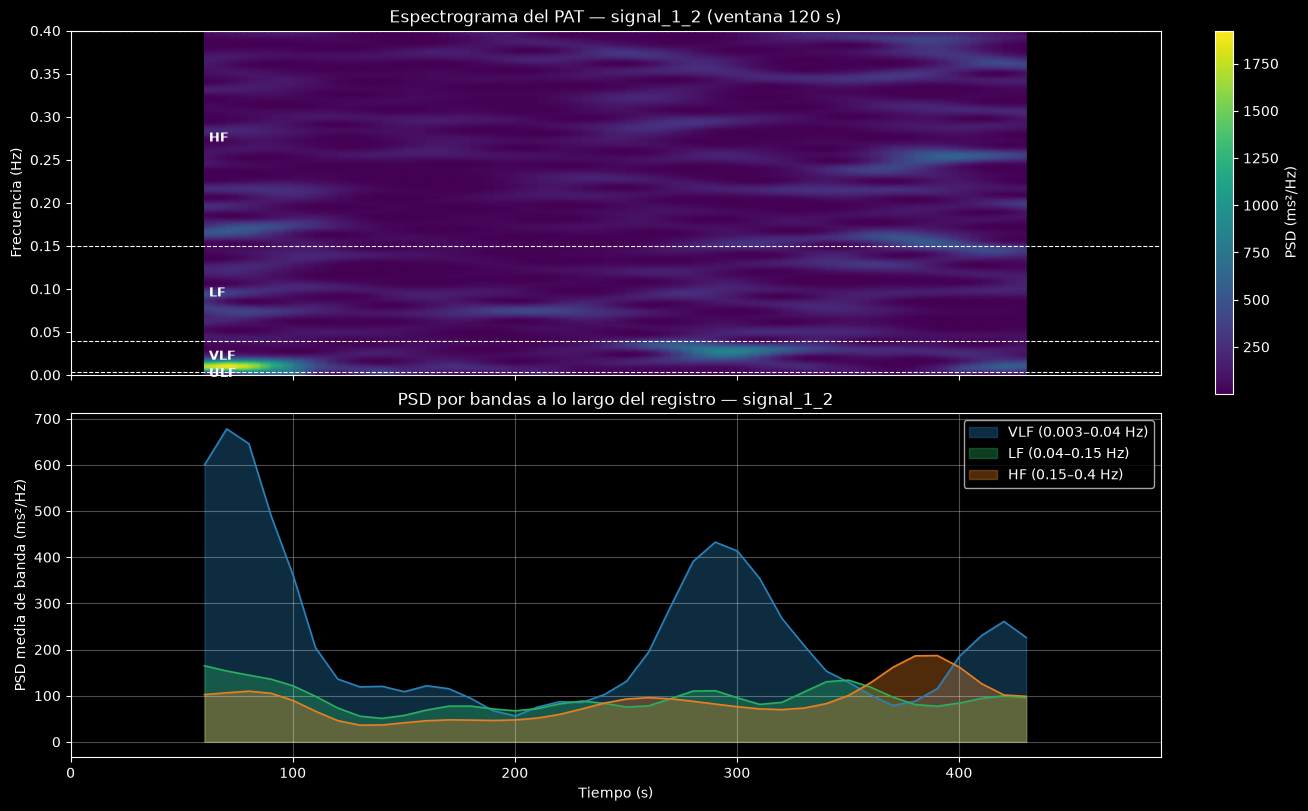

In [36]:
graf_espectrograma("signal_1_2")

### Espectrograma — signal_1_3

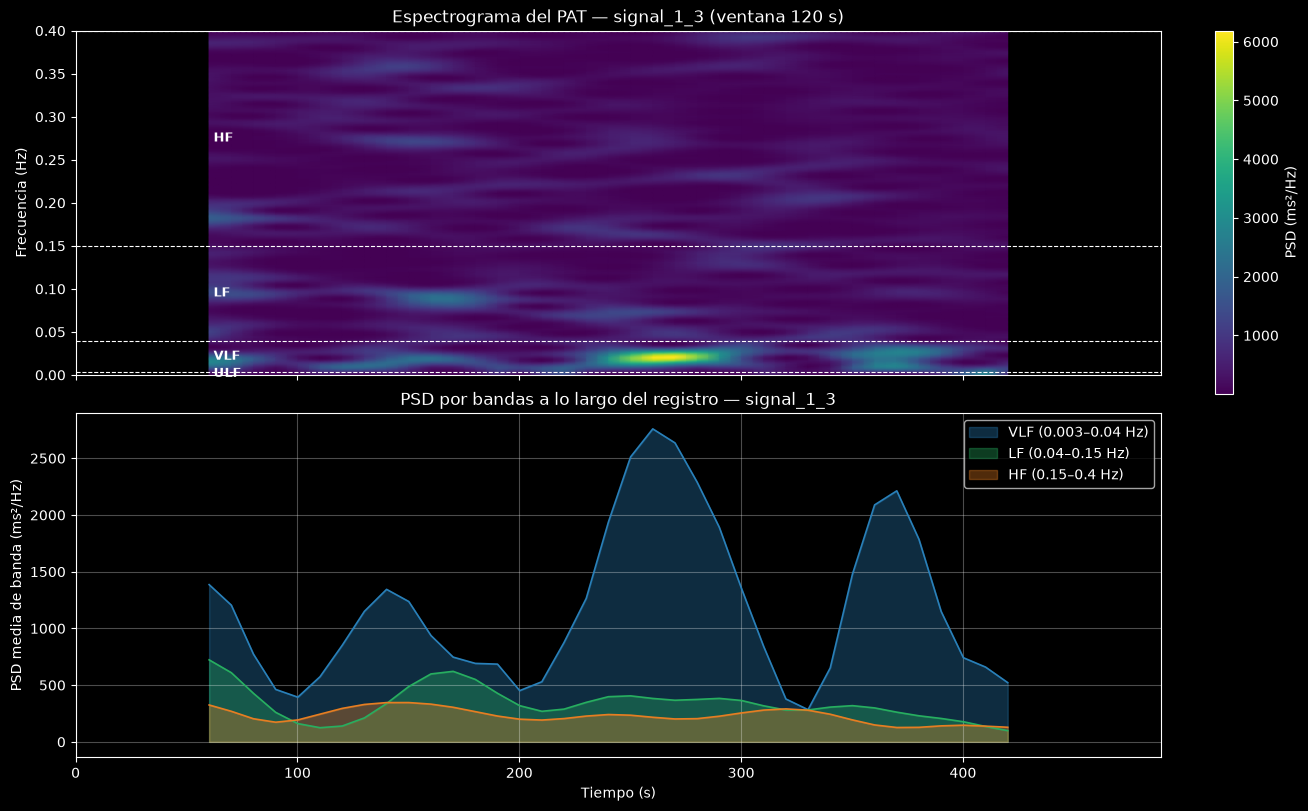

In [37]:
graf_espectrograma("signal_1_3")

### Espectrograma — signal_3_1

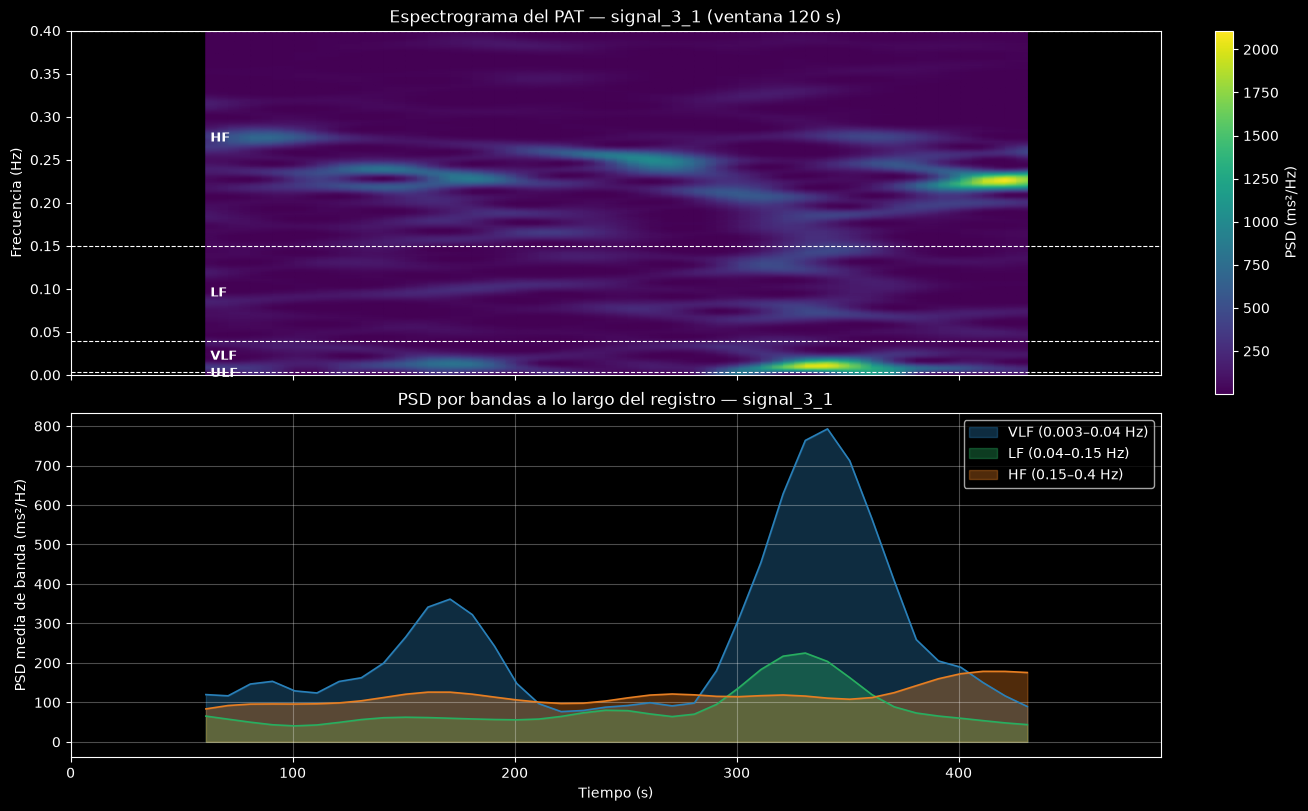

In [38]:
graf_espectrograma("signal_3_1")

### Espectrograma — signal_3_2

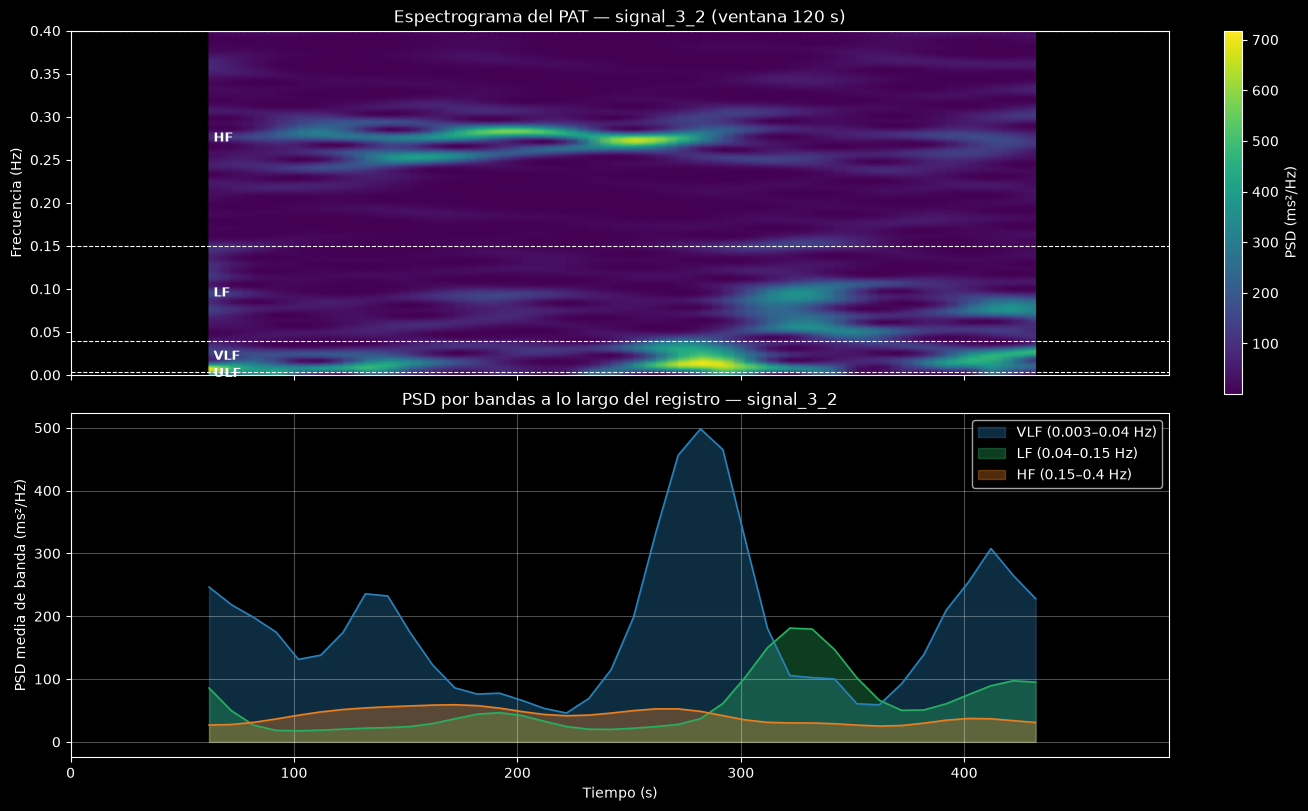

In [39]:
graf_espectrograma("signal_3_2")

### Espectrograma — signal_3_3

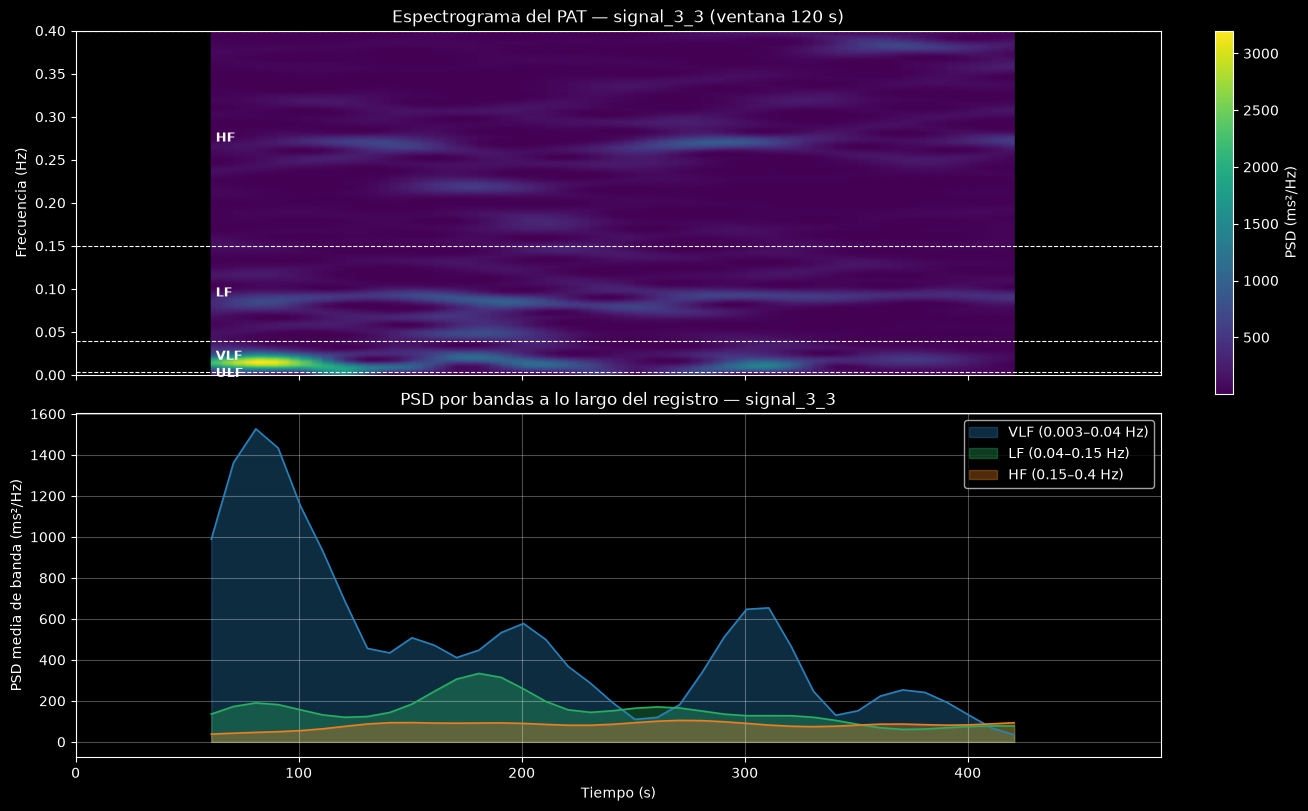

In [40]:
graf_espectrograma("signal_3_3")

# 3° Tabla resumen — todas las señales
Además de lo pedido (PAT medio, potencia por banda, %, ULF/VLF, LF/HF) se agregan, por ser comparables entre señales:
- **Calidad:** canal PPG elegido, SQI, sensibilidad y PPV de Pan-Tompkins vs `peaks`, % de latidos válidos.
- **Dominio temporal:** DE, CV (dispersión relativa, independiente del PAT medio), RMSSD (variabilidad latido a latido), mín/máx.
- **FC** y **r(PAT,RR)**: acople entre tiempo de tránsito y ciclo cardíaco.
- **LFnu / HFnu:** unidades normalizadas, comparables aunque cambie la potencia total.
- **Pico HF → FR estimada:** la modulación respiratoria del PAT.

In [41]:
resumen = pd.DataFrame([R["fila"] for R in RES]).set_index("señal")
resumen.to_csv(f"{DIR_TAB}/resumen_pat.csv", float_format="%.4f")
pd.set_option("display.float_format", "{:.3f}".format)
tabla = resumen.T
tabla["media"] = resumen.select_dtypes("number").mean()
tabla["DE"] = resumen.select_dtypes("number").std()
tabla

señal,signal_1_1,signal_1_2,signal_1_3,signal_3_1,signal_3_2,signal_3_3,media,DE
duración (s),508.052,491.804,490.548,492.298,493.174,487.454,493.888,7.219
canal PPG,pleth_3,pleth_3,pleth_3,pleth_3,pleth_3,pleth_3,NaN,NaN
SQI PPG,0.849,0.823,0.798,0.809,0.784,0.810,0.812,0.022
sens. R (%),100.000,96.871,99.393,100.000,99.858,98.256,99.063,1.261
PPV R (%),100.000,97.892,99.544,100.000,99.858,99.558,99.475,0.802
latidos,612,758,657,602,702,678,668.167,58.256
válidos (%),98.529,95.515,98.021,100.000,99.003,97.935,98.167,1.503
FC (lpm),72.392,93.664,80.668,73.549,85.584,84.635,81.749,8.012
PAT medio (ms),249.860,237.810,242.905,291.108,267.636,276.519,260.973,20.884
PAT DE (ms),5.714,9.512,14.402,7.362,5.516,9.587,8.682,3.311


# 4° Tabla — 6 señales
Parámetros en filas, señales en columnas, más media y DE entre señales. Se exporta a `salidas/tablas/resumen_pat.xlsx` (con formato, lista para el informe).

In [42]:
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

GRUPOS = {  # parámetro -> sección de la tabla
    "Calidad de señal": ["duración (s)", "canal PPG", "SQI PPG", "sens. R (%)", "PPV R (%)", "latidos", "válidos (%)"],
    "Dominio temporal": ["FC (lpm)", "PAT medio (ms)", "PAT DE (ms)", "PAT CV (%)", "PAT RMSSD (ms)",
                         "PAT mín (ms)", "PAT máx (ms)", "r(PAT,RR)"],
    "PSD por bandas (ms²)": [f"{b} (ms²)" for b in BANDAS] + ["Total (ms²)"],
    "Contribución (%)": [f"{b} (%)" for b in BANDAS],
    "Ratios / normalizadas": ["ULF/VLF", "LF/HF", "LFnu", "HFnu", "pico HF (Hz)", "FR estimada (rpm)"],
}
filas = [(g, p) for g, ps in GRUPOS.items() for p in ps]
final = tabla.loc[[p for _, p in filas]]
final.index = pd.MultiIndex.from_tuples(filas, names=["Sección", "Parámetro"])
display(final)

ruta = f"{DIR_TAB}/resumen_pat.xlsx"
with pd.ExcelWriter(ruta, engine="openpyxl") as xw:
    final.to_excel(xw, sheet_name="Resumen")
    ws = xw.sheets["Resumen"]
    borde = Border(*(Side(style="thin", color="999999"),) * 4)
    for fila in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=ws.max_column):
        for c in fila:
            c.border = borde
            if isinstance(c.value, float):
                c.number_format = "0.000" if abs(c.value) < 10 else "0.0"
            c.alignment = Alignment(horizontal="center", vertical="center")
    for c in ws[1]:
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor="2C3E50")
    for c in ws["A"][1:]:
        c.font = Font(bold=True)
    ws.column_dimensions["A"].width = 24
    ws.column_dimensions["B"].width = 20
    for col in "CDEFGHIJ":
        ws.column_dimensions[col].width = 13
    ws.freeze_panes = "C2"
print(f"Guardado: {ruta}")

señal                                   signal_1_1 signal_1_2 signal_1_3  \
Sección               Parámetro                                            
Calidad de señal      duración (s)         508.052    491.804    490.548   
                      canal PPG            pleth_3    pleth_3    pleth_3   
                      SQI PPG                0.849      0.823      0.798   
                      sens. R (%)          100.000     96.871     99.393   
                      PPV R (%)            100.000     97.892     99.544   
                      latidos                  612        758        657   
                      válidos (%)           98.529     95.515     98.021   
Dominio temporal      FC (lpm)              72.392     93.664     80.668   
                      PAT medio (ms)       249.860    237.810    242.905   
                      PAT DE (ms)            5.714      9.512     14.402   
                      PAT CV (%)             2.287      4.000      5.929   
                      PAT RMSSD (ms)         7.415     13.269     16.396   
                      PAT mín (ms)         233.999    213.425    200.859   
                      PAT máx (ms)         265.832    265.165    285.457   
                      r(PAT,RR)             -0.032      0.016      0.088   
PSD por bandas (ms²)  ULF (ms²)              0.268      1.442     23.528   
                      VLF (ms²)              4.186      7.134     51.751   
                      LF (ms²)               6.055      9.477     41.875   
                      HF (ms²)               9.965     18.431     59.211   
                      Total (ms²)           20.474     36.485    176.365   
Contribución (%)      ULF (%)                1.307      3.953     13.340   
                      VLF (%)               20.446     19.554     29.343   
                      LF (%)                29.575     25.976     23.743   
                      HF (%)                48.672     50.517     33.573   
Ratios / normalizadas ULF/VLF                0.064      0.202      0.455   
                      LF/HF                  0.608      0.514      0.707   
                      LFnu                  37.797     33.959     41.425   
                      HFnu                  62.203     66.041     58.575   
                      pico HF (Hz)           0.236      0.371      0.357   
                      FR estimada (rpm)     14.158     22.284     21.398   

señal                                   signal_3_1 signal_3_2 signal_3_3  \
Sección               Parámetro                                            
Calidad de señal      duración (s)         492.298    493.174    487.454   
                      canal PPG            pleth_3    pleth_3    pleth_3   
                      SQI PPG                0.809      0.784      0.810   
                      sens. R (%)          100.000     99.858     98.256   
                      PPV R (%)            100.000     99.858     99.558   
                      latidos                  602        702        678   
                      válidos (%)          100.000     99.003     97.935   
Dominio temporal      FC (lpm)              73.549     85.584     84.635   
                      PAT medio (ms)       291.108    267.636    276.519   
                      PAT DE (ms)            7.362      5.516      9.587   
                      PAT CV (%)             2.529      2.061      3.467   
                      PAT RMSSD (ms)         7.257      4.772      8.463   
                      PAT mín (ms)         272.157    251.371    255.303   
                      PAT máx (ms)         310.024    283.279    305.914   
                      r(PAT,RR)             -0.193     -0.209     -0.179   
PSD por bandas (ms²)  ULF (ms²)              1.957      0.761     11.009   
                      VLF (ms²)             10.415      7.515     15.640   
                      LF (ms²)               9.843      5.823     19.011   
                      HF (ms²)              28.

Guardado: salidas/tablas/resumen_pat.xlsx


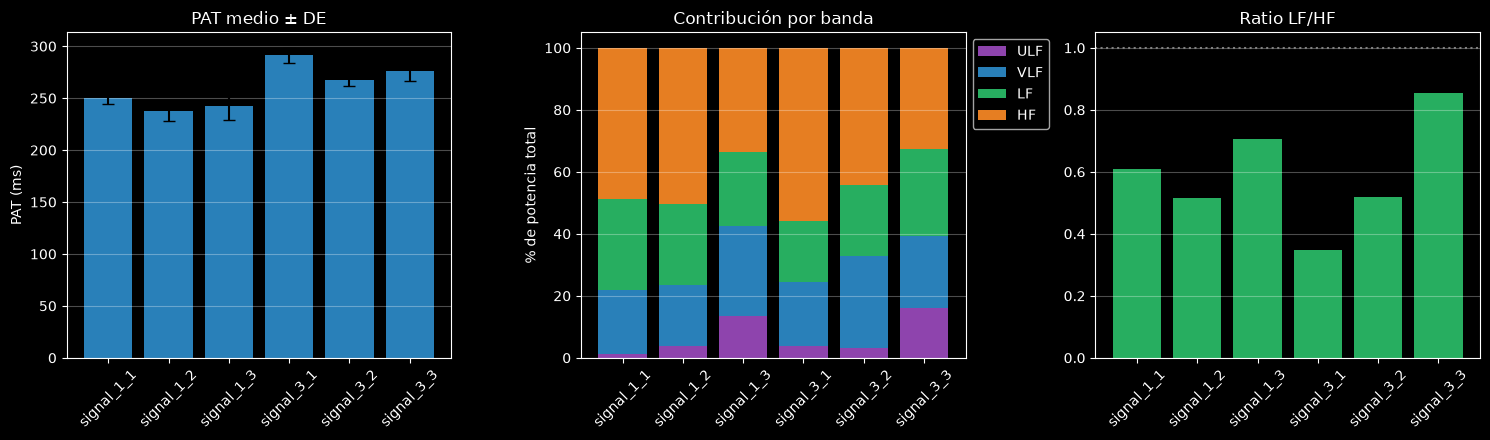

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
x = resumen.index
ax[0].bar(x, resumen["PAT medio (ms)"], yerr=resumen["PAT DE (ms)"], capsize=4, color="#2980b9")
ax[0].set_ylabel("PAT (ms)"); ax[0].set_title("PAT medio ± DE")
fondo = np.zeros(len(x))
for b, (_, _, col) in BANDAS.items():
    ax[1].bar(x, resumen[f"{b} (%)"], bottom=fondo, color=col, label=b)
    fondo += resumen[f"{b} (%)"].to_numpy()
ax[1].set_ylabel("% de potencia total"); ax[1].set_title("Contribución por banda"); ax[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[2].bar(x, resumen["LF/HF"], color="#27ae60")
ax[2].axhline(1, color="gray", ls=":")
ax[2].set_title("Ratio LF/HF")
for a in ax:
    a.tick_params(axis="x", rotation=45); a.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{DIR_GRAF}/resumen_pat.png", dpi=120)
plt.show()